# 08 - Comparaison Globale

## 1. Protocole de synthese et garde-fous

Cette synthese ne vise pas a conclure definitivement sur un meilleur modele unique.
Elle organise les artefacts canoniques pour formuler des hypotheses sur le classement confirmatoire,
le role du preprocessing, la stabilite inter-plis, le cout temporel et la complementarite potentielle
des erreurs en vue d'une future combinaison de modeles.

Regle de lecture :
- les lignes `tuned` en `nested_cv` servent a la comparaison confirmatoire provisoire ;
- les variantes non tunees restent exploratoires et servent a expliquer les signaux observes ;
- aucune conclusion finale n'est arretee dans ce notebook.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from src.config import RESULTS_DIR
from src.artifacts import charger_predictions_modele, charger_tableau_mesures_valides
from src.data import charger_donnees_modelisation
from src.evaluation import evaluer_dummy_classifier, matrice_confusion_normalisee, top_confusions
from src.notebook_support import (
    NOTEBOOK_MODEL_SPECS,
    charger_ou_generer_predictions_variante,
    construire_tableau_complementarite_erreurs,
    construire_tableau_holdout_global,
    construire_tableau_plis_tuned_global,
)
from src.plots import tracer_barres_comparaison, tracer_matrice_confusion, tracer_temps_vs_performance, tracer_top_confusions


## 2. Baseline de reference

Le `DummyClassifier` fournit le plancher commun a toutes les comparaisons de performance.


In [2]:
model_names = sorted(NOTEBOOK_MODEL_SPECS.keys())
OUTPUT_ROOT = RESULTS_DIR
split = charger_donnees_modelisation(output_root=OUTPUT_ROOT)
X, y, label_encoder = split.X_dev, split.y_dev, split.label_encoder
baseline_dummy = pd.DataFrame([evaluer_dummy_classifier(X, y)]).assign(
    selection_protocol="simple_cv",
    evaluation_stage="baseline",
    modele="dummy",
    variante="most_frequent",
)
display(baseline_dummy.round(4))


,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,fit_time_mean,score_time_mean,elapsed_seconds,n_splits,modele,variante,selection_protocol,evaluation_stage
0,0.0101,0.0,0.0002,0.0,0.0101,0.0002,0.001,0.0018,0.0255,5,dummy,most_frequent,simple_cv,baseline


## 3. Résultats confirmatoires par modèle

Le tableau ci-dessous ne retient que les variantes `tuned` evaluees en `nested CV`.
Il sert a etablir un classement confirmatoire provisoire et non une conclusion finale.


,modele,variante,val_f1_macro_mean,val_f1_macro_std,val_accuracy_mean,elapsed_seconds,selection_protocol
0,regression_logistique,tuned,0.9860,0.0061,0.9869,79.8994,nested_cv
1,svm,tuned,0.9853,0.0109,0.9869,109.9879,nested_cv
2,foret_aleatoire,tuned,0.9789,0.0094,0.9808,385.3213,nested_cv
3,mlp,tuned,0.9615,0.0200,0.9636,40.2638,nested_cv
4,perceptron,tuned,0.8917,0.0271,0.9040,41.5248,nested_cv
5,arbre_decision,tuned,0.5072,0.0539,0.5384,13.8971,nested_cv


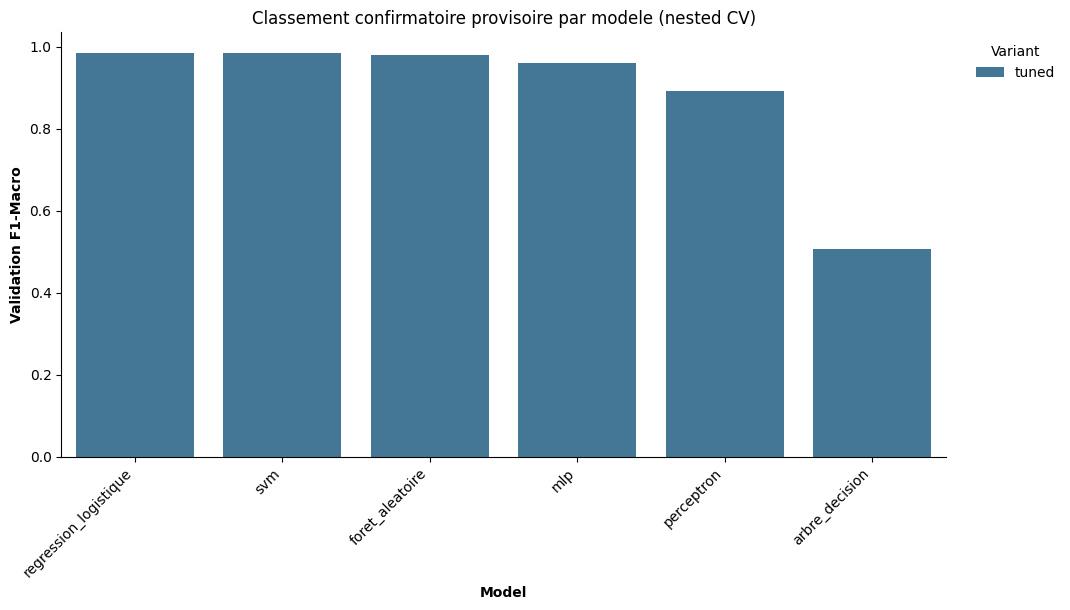

In [3]:
mesures = charger_tableau_mesures_valides(modeles=model_names, metrics_dir=OUTPUT_ROOT)
best_tuned = (
    mesures.loc[mesures["evaluation_stage"] == "tuned"]
    .sort_values(["val_f1_macro_mean", "val_accuracy_mean"], ascending=False)
    .reset_index(drop=True)
)
if best_tuned["modele"].nunique() != len(model_names):
    raise RuntimeError(
        "Synthese globale bloquee: tous les modeles doivent disposer d'un resultat tuned valide avant le classement provisoire."
    )

display(best_tuned[[
    "modele",
    "variante",
    "val_f1_macro_mean",
    "val_f1_macro_std",
    "val_accuracy_mean",
    "elapsed_seconds",
    "selection_protocol",
]].round(4))
tracer_barres_comparaison(
    best_tuned,
    metrique="val_f1_macro_mean",
    titre="Classement confirmatoire provisoire par modele (nested CV)",
)
plt.show()


## 4. Variantes exploratoires et coût

Cette section se limite a deux lectures complementaires :
- un graphe confirmatoire `temps vs performance` sur les seules lignes `tuned` ;
- un tableau exploratoire des meilleures variantes non tunees par modele, pour quantifier
  l'effet du preprocessing et du tuning avant toute conclusion.


,modele,variante,val_f1_macro_mean,val_accuracy_mean,generalization_gap_f1_macro,delta_f1_vs_default,elapsed_seconds
4,regression_logistique,scaled_only,0.9860,0.9869,0.0140,0.4315,19.3188
5,svm,scaled_only,0.9821,0.9838,0.0151,0.0906,3.5566
1,foret_aleatoire,default,0.9768,0.9788,0.0232,0.0000,10.4410
2,mlp,scaled_pca,0.9599,0.9636,0.0339,0.6287,2.3110
3,perceptron,scaled_pca,0.8846,0.8939,0.1100,0.1147,1.0420
0,arbre_decision,default,0.6368,0.6586,0.3632,0.0000,1.1462


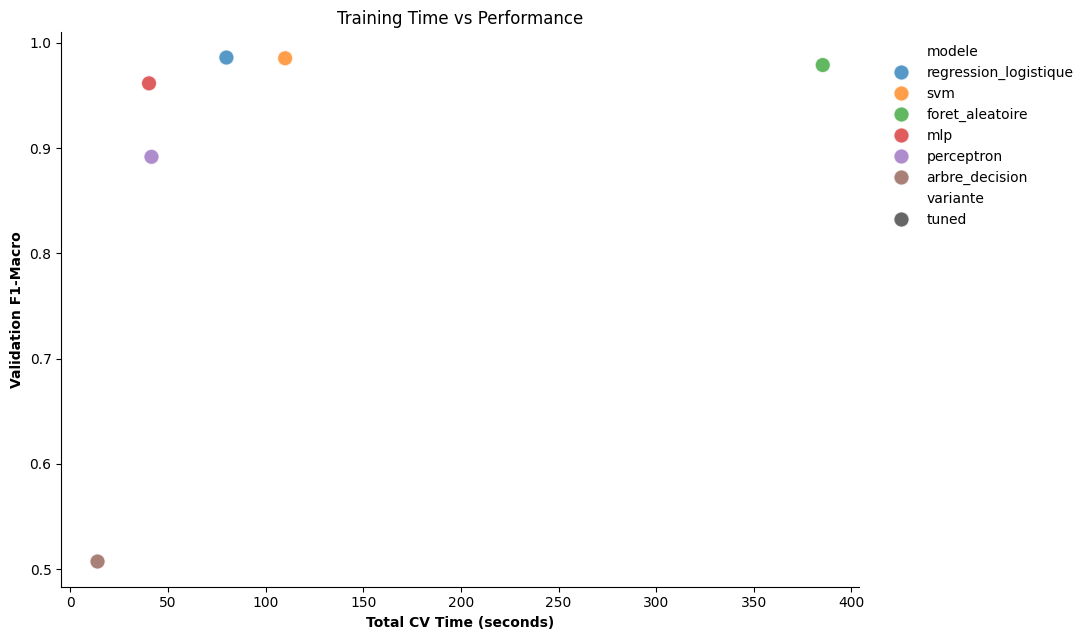

In [4]:
tableau_exploratoire = (
    mesures.loc[mesures["evaluation_stage"] != "tuned"]
    .sort_values(["modele", "val_f1_macro_mean"], ascending=[True, False])
    .reset_index(drop=True)
)

best_exploratoire = (
    tableau_exploratoire
    .sort_values(["modele", "val_f1_macro_mean"], ascending=[True, False])
    .groupby("modele", as_index=False)
    .head(1)
    .copy()
)

defaults = (
    tableau_exploratoire.loc[tableau_exploratoire["variante"] == "default", [
        "modele",
        "val_f1_macro_mean",
        "val_accuracy_mean",
    ]]
    .rename(columns={
        "val_f1_macro_mean": "default_f1_macro",
        "val_accuracy_mean": "default_accuracy",
    })
)

best_exploratoire = best_exploratoire.merge(defaults, on="modele", how="left")
best_exploratoire["delta_f1_vs_default"] = (
    best_exploratoire["val_f1_macro_mean"] - best_exploratoire["default_f1_macro"]
)

display(best_exploratoire[[
    "modele",
    "variante",
    "val_f1_macro_mean",
    "val_accuracy_mean",
    "generalization_gap_f1_macro",
    "delta_f1_vs_default",
    "elapsed_seconds",
]].sort_values("val_f1_macro_mean", ascending=False).round(4))

tracer_temps_vs_performance(
    best_tuned,
    metrique="val_f1_macro_mean",
)
plt.show()


### Stabilite inter-plis des meilleurs modeles

Le tableau ci-dessous reconstitue les scores par pli externe pour les principaux candidats `tuned`.
Il sert a juger la stabilite relative des meilleurs modeles sans transformer les ecarts fins en conclusion definitive.


In [5]:
top_models = best_tuned.head(3)["modele"].tolist()
predictions_top = {modele: charger_predictions_modele(modele, "tuned", root=OUTPUT_ROOT) for modele in top_models}
tableau_plis_tuned = construire_tableau_plis_tuned_global(
    X,
    y,
    predictions_top,
    n_splits=int(best_tuned.iloc[0]["n_splits"]),
)
display(tableau_plis_tuned.pivot(index="fold", columns="modele", values="val_f1_macro").round(4))
display(tableau_plis_tuned.pivot(index="fold", columns="modele", values="val_accuracy").round(4))


modele,foret_aleatoire,regression_logistique,svm
fold,,,
1,0.9838,0.9785,0.9785
2,0.9623,0.9838,0.9946
3,0.9838,0.9892,0.9697
4,0.9838,0.9838,0.9892
5,0.9805,0.9946,0.9946


modele,foret_aleatoire,regression_logistique,svm
fold,,,
1,0.9848,0.9798,0.9798
2,0.9646,0.9848,0.9949
3,0.9848,0.9899,0.9747
4,0.9848,0.9848,0.9899
5,0.9848,0.9949,0.9949


## 5. Diagnostics multiclasses du meilleur modele

Le modele en tete du classement provisoire est ici traite comme **candidat confirmatoire courant**.
Cette section sert uniquement a documenter les erreurs multiclasses les plus saillantes du candidat
actuellement le mieux classe, sans transformer ce rang provisoire en conclusion finale.


,candidat_confirmatoire_courant
0,regression_logistique


,classe_vraie,classe_predite,nombre_erreurs
0,Lithocarpus_Edulis,Lithocarpus_Cleistocarpus,2
1,Callicarpa_Bodinieri,Viburnum_x_Rhytidophylloides,1
2,Cornus_Macrophylla,Phildelphus,1
3,Eucalyptus_Neglecta,Eucalyptus_Glaucescens,1
4,Populus_Adenopoda,Quercus_Ilex,1
5,Prunus_X_Shmittii,Morus_Nigra,1
6,Quercus_Castaneifolia,Quercus_Kewensis,1
7,Quercus_Infectoria_sub,Cercis_Siliquastrum,1
8,Quercus_Palustris,Quercus_Shumardii,1
9,Quercus_Pontica,Quercus_Agrifolia,1


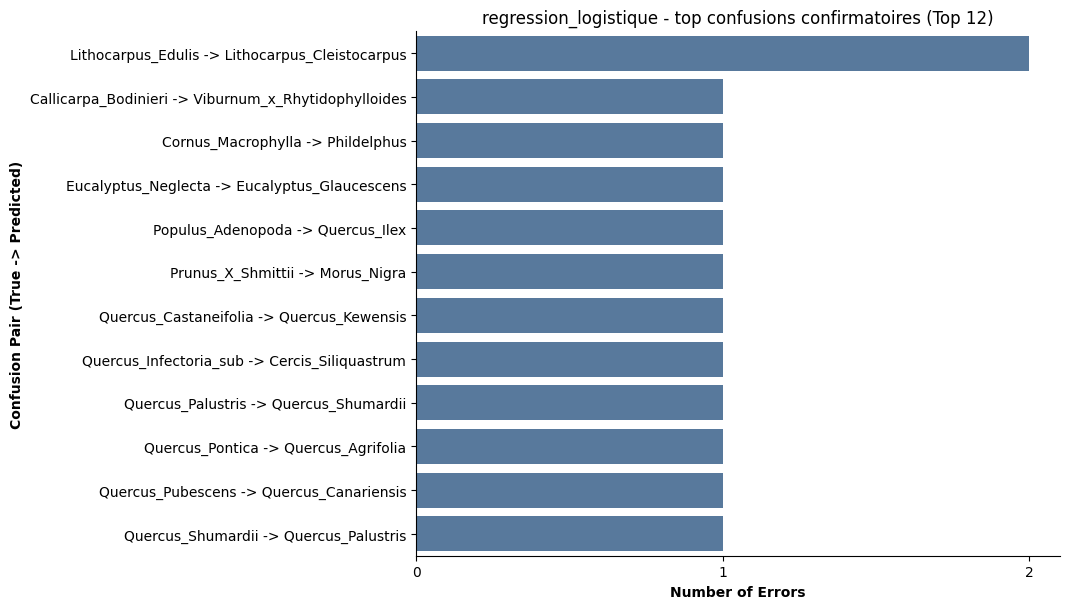

In [6]:
candidat_courant = best_tuned.iloc[0]["modele"]
candidat_predictions = charger_predictions_modele(candidat_courant, "tuned", root=OUTPUT_ROOT)
candidat_confusions = top_confusions(
    candidat_predictions["y_true"].to_numpy(),
    candidat_predictions["y_pred"].to_numpy(),
    label_encoder=label_encoder,
    top_n=15,
)
display(pd.DataFrame([{"candidat_confirmatoire_courant": candidat_courant}]))
display(candidat_confusions.round(4))
if not candidat_confusions.empty:
    tracer_top_confusions(
        candidat_confusions,
        top_n=min(15, len(candidat_confusions)),
        titre=f"{candidat_courant} - top confusions confirmatoires",
    )
    plt.show()


### Matrices de confusion par modele et variante

Les matrices ci-dessous servent a comparer les profils d'erreurs a travers tous les modeles et toutes les variantes publiees.
- pour `tuned`, les predictions proviennent des artefacts `OOF` de la `nested CV` ;
- pour les variantes non tunees, les predictions sont reconstruites en `simple CV` avec le protocole partage.

Cette section reste descriptive : elle documente les erreurs sans conclure sur une superiorite definitive.


### arbre_decision

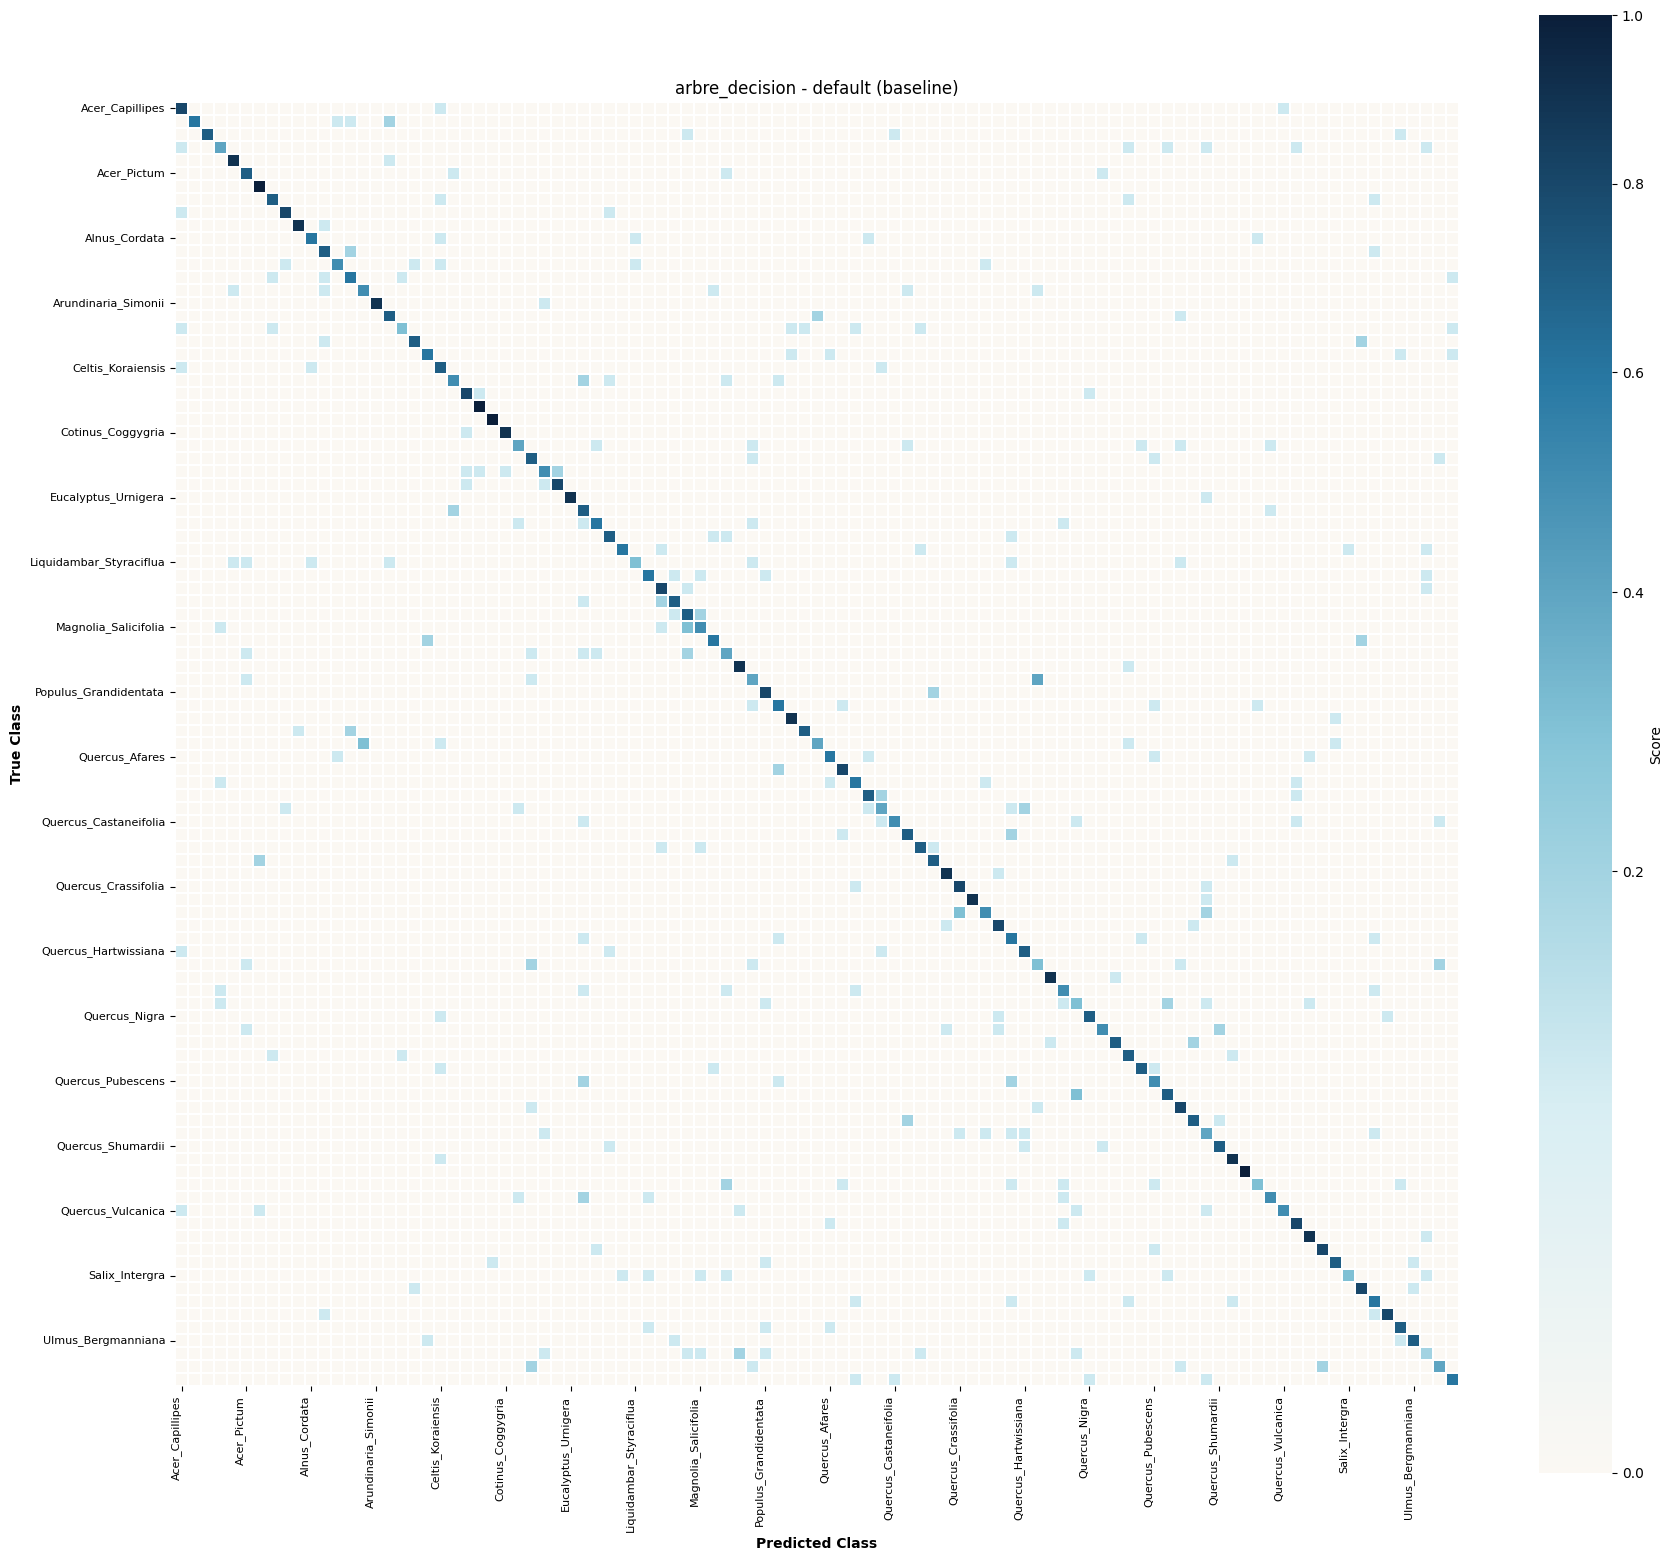

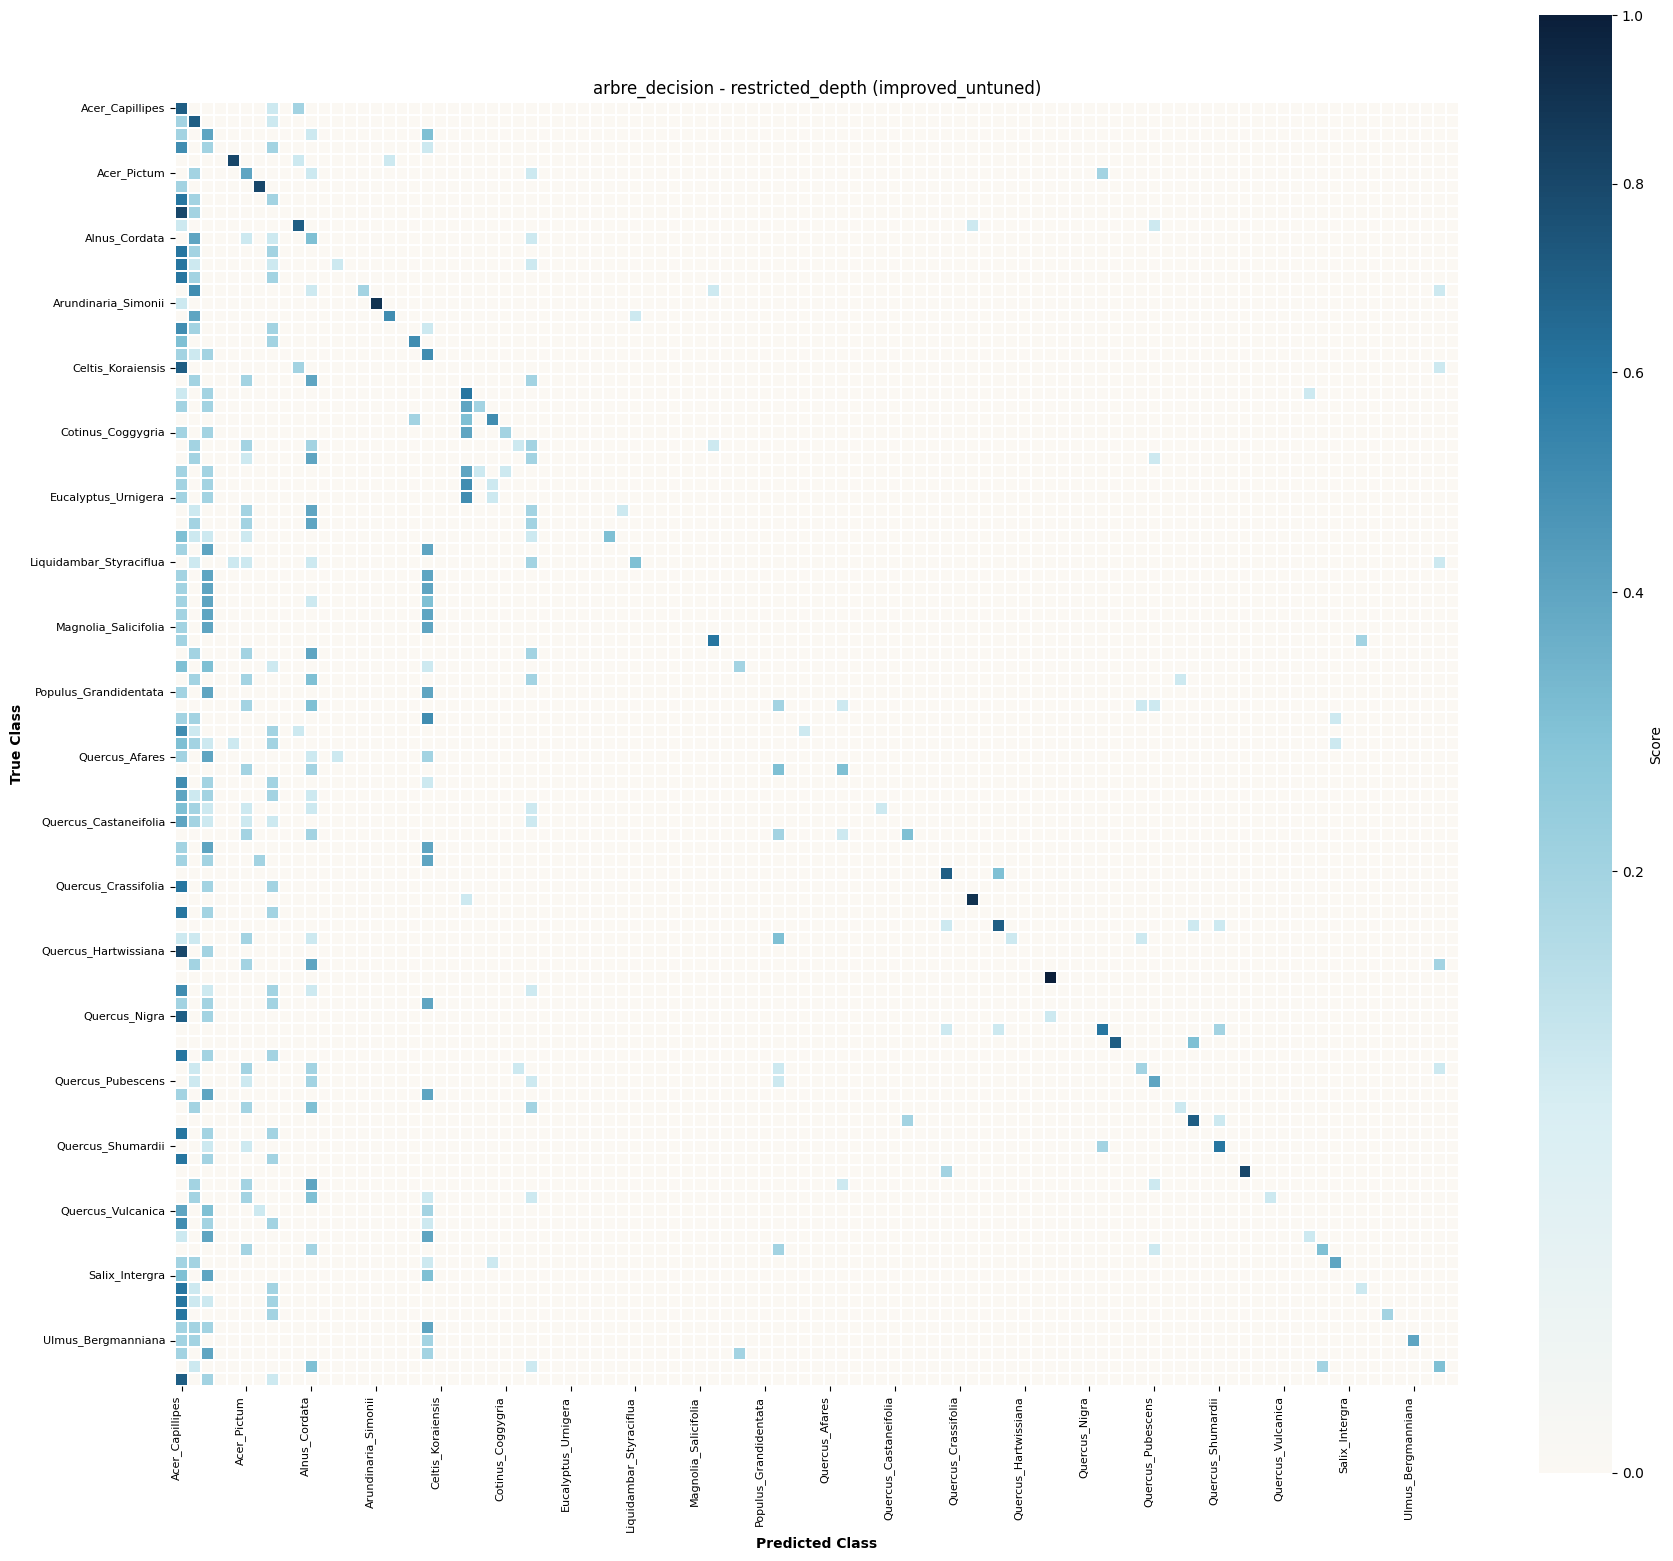

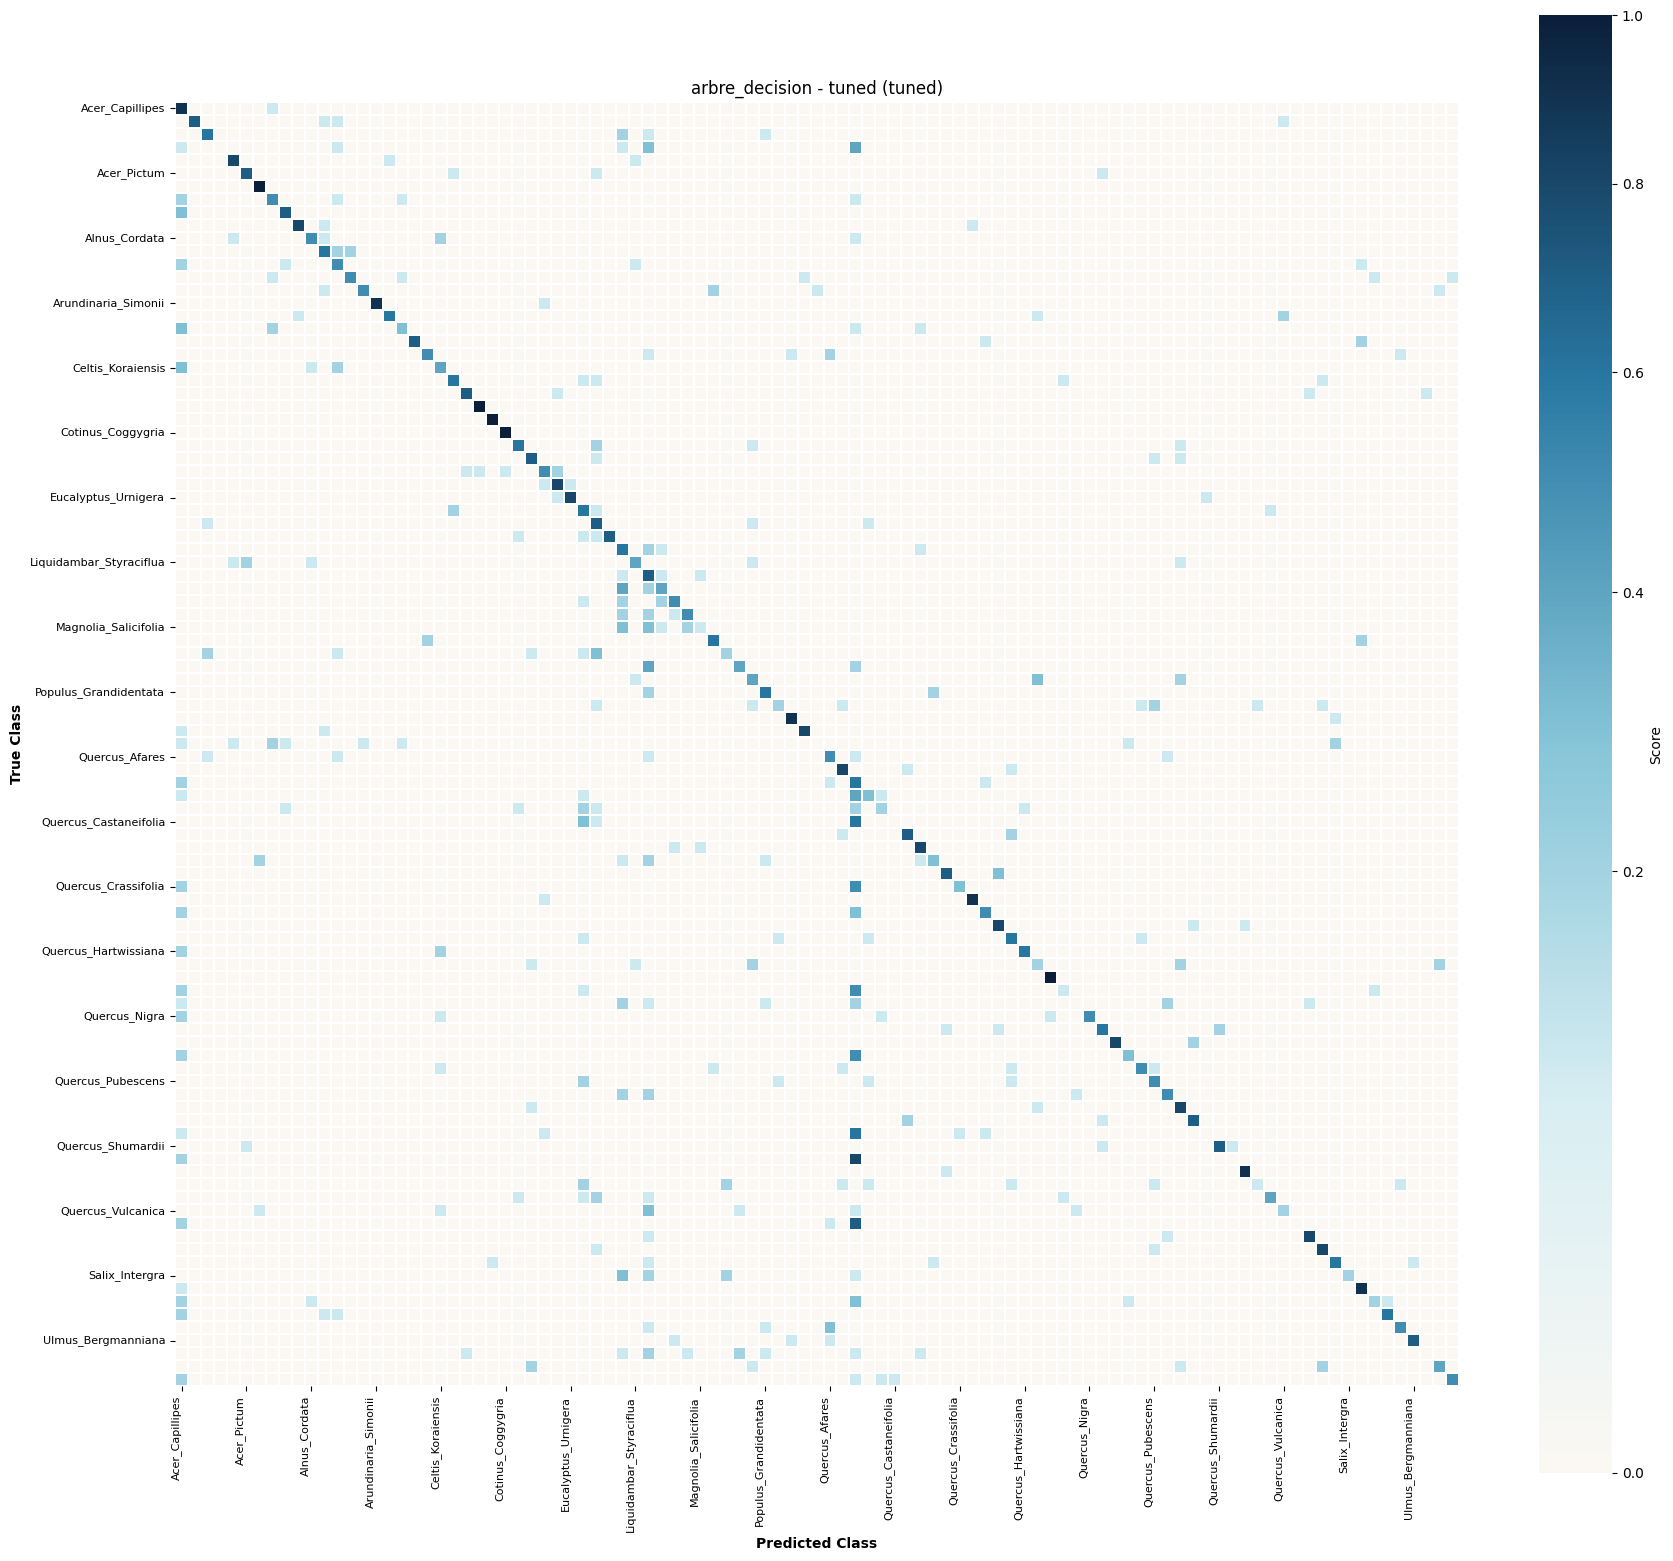

### foret_aleatoire

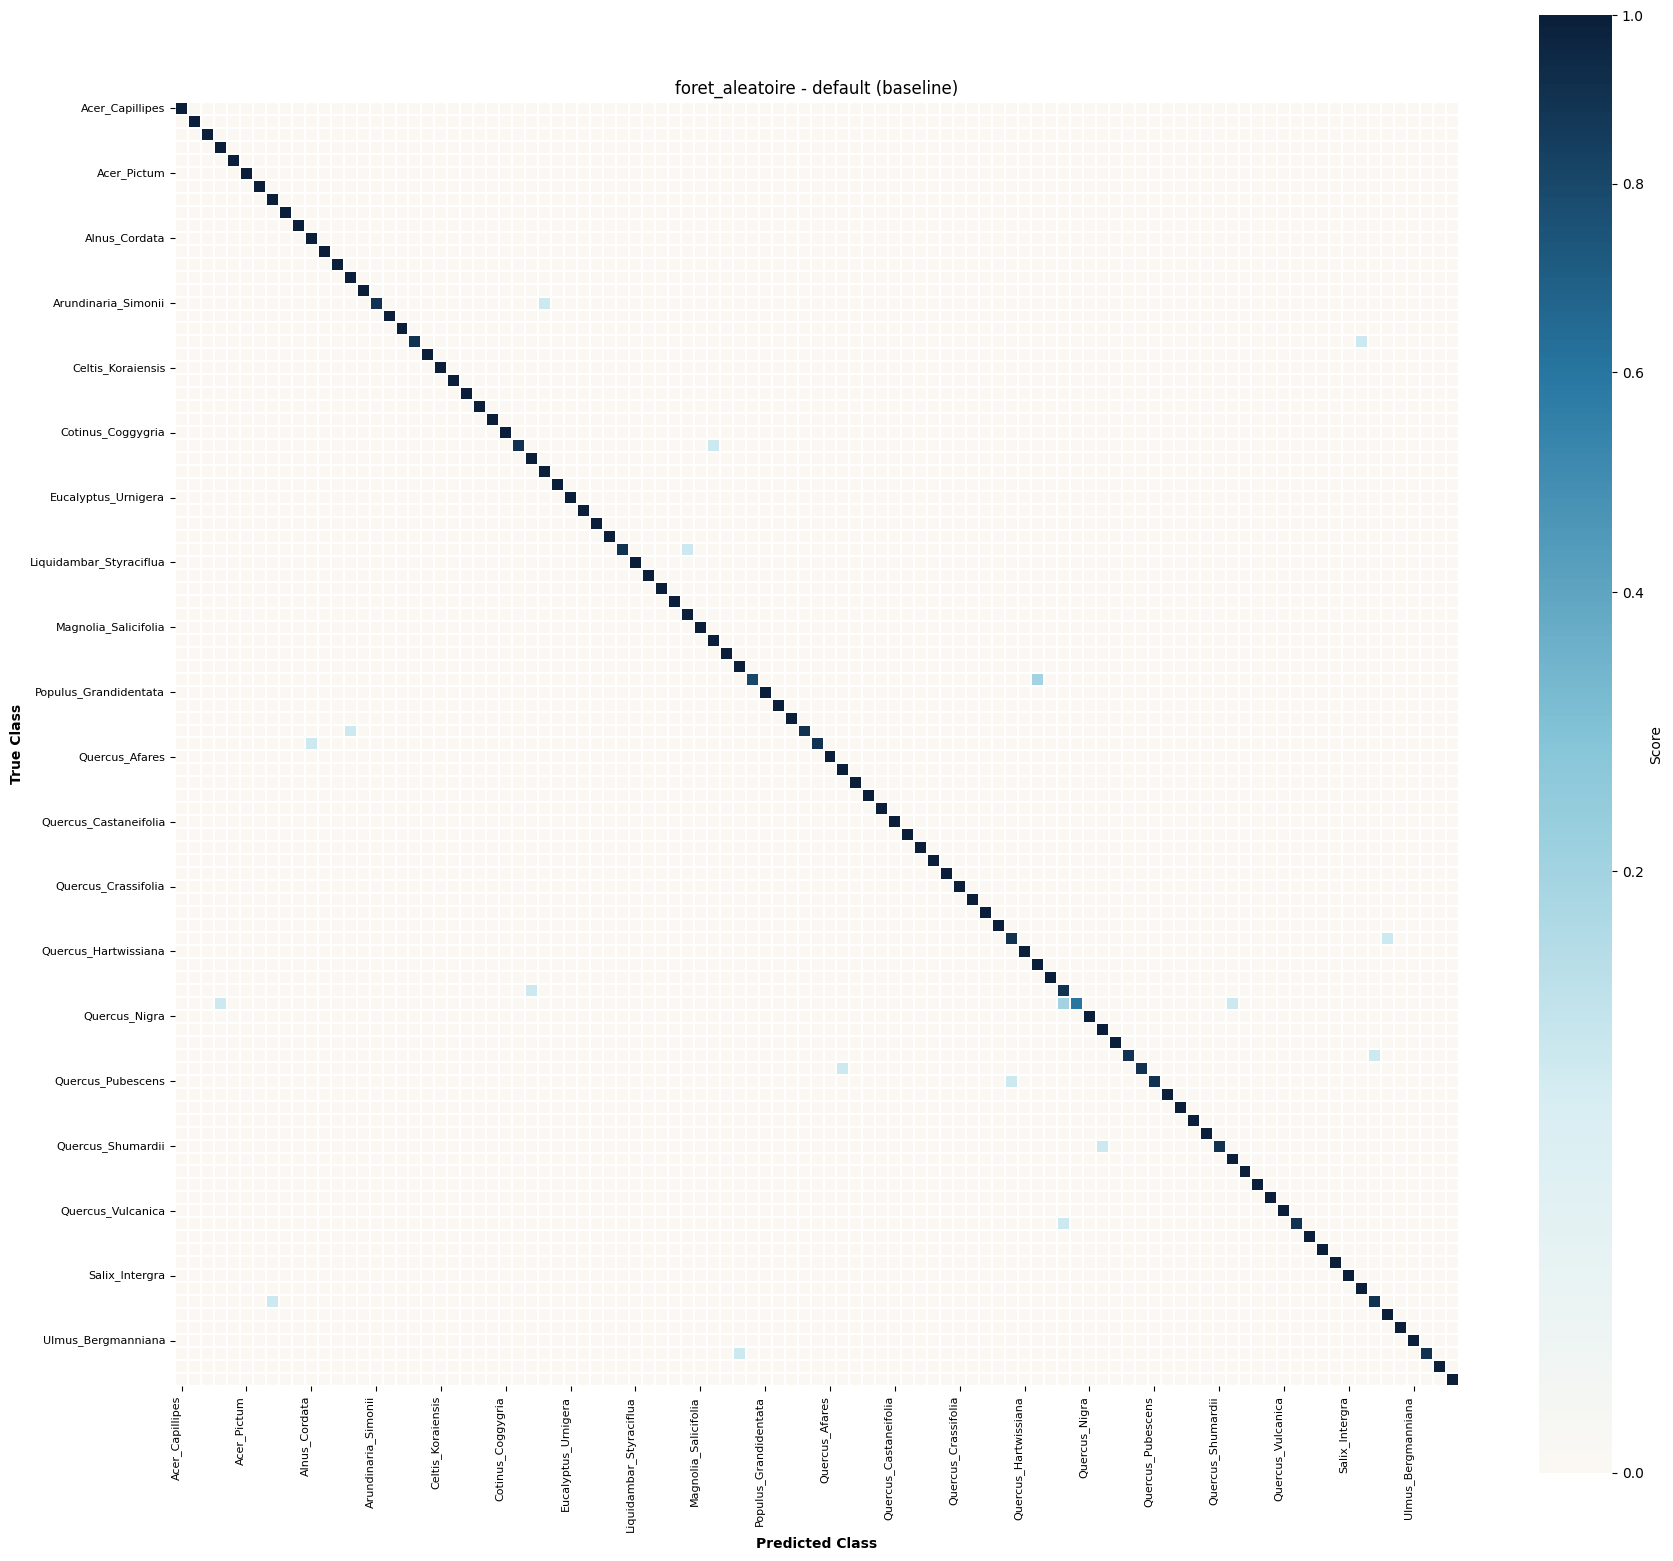

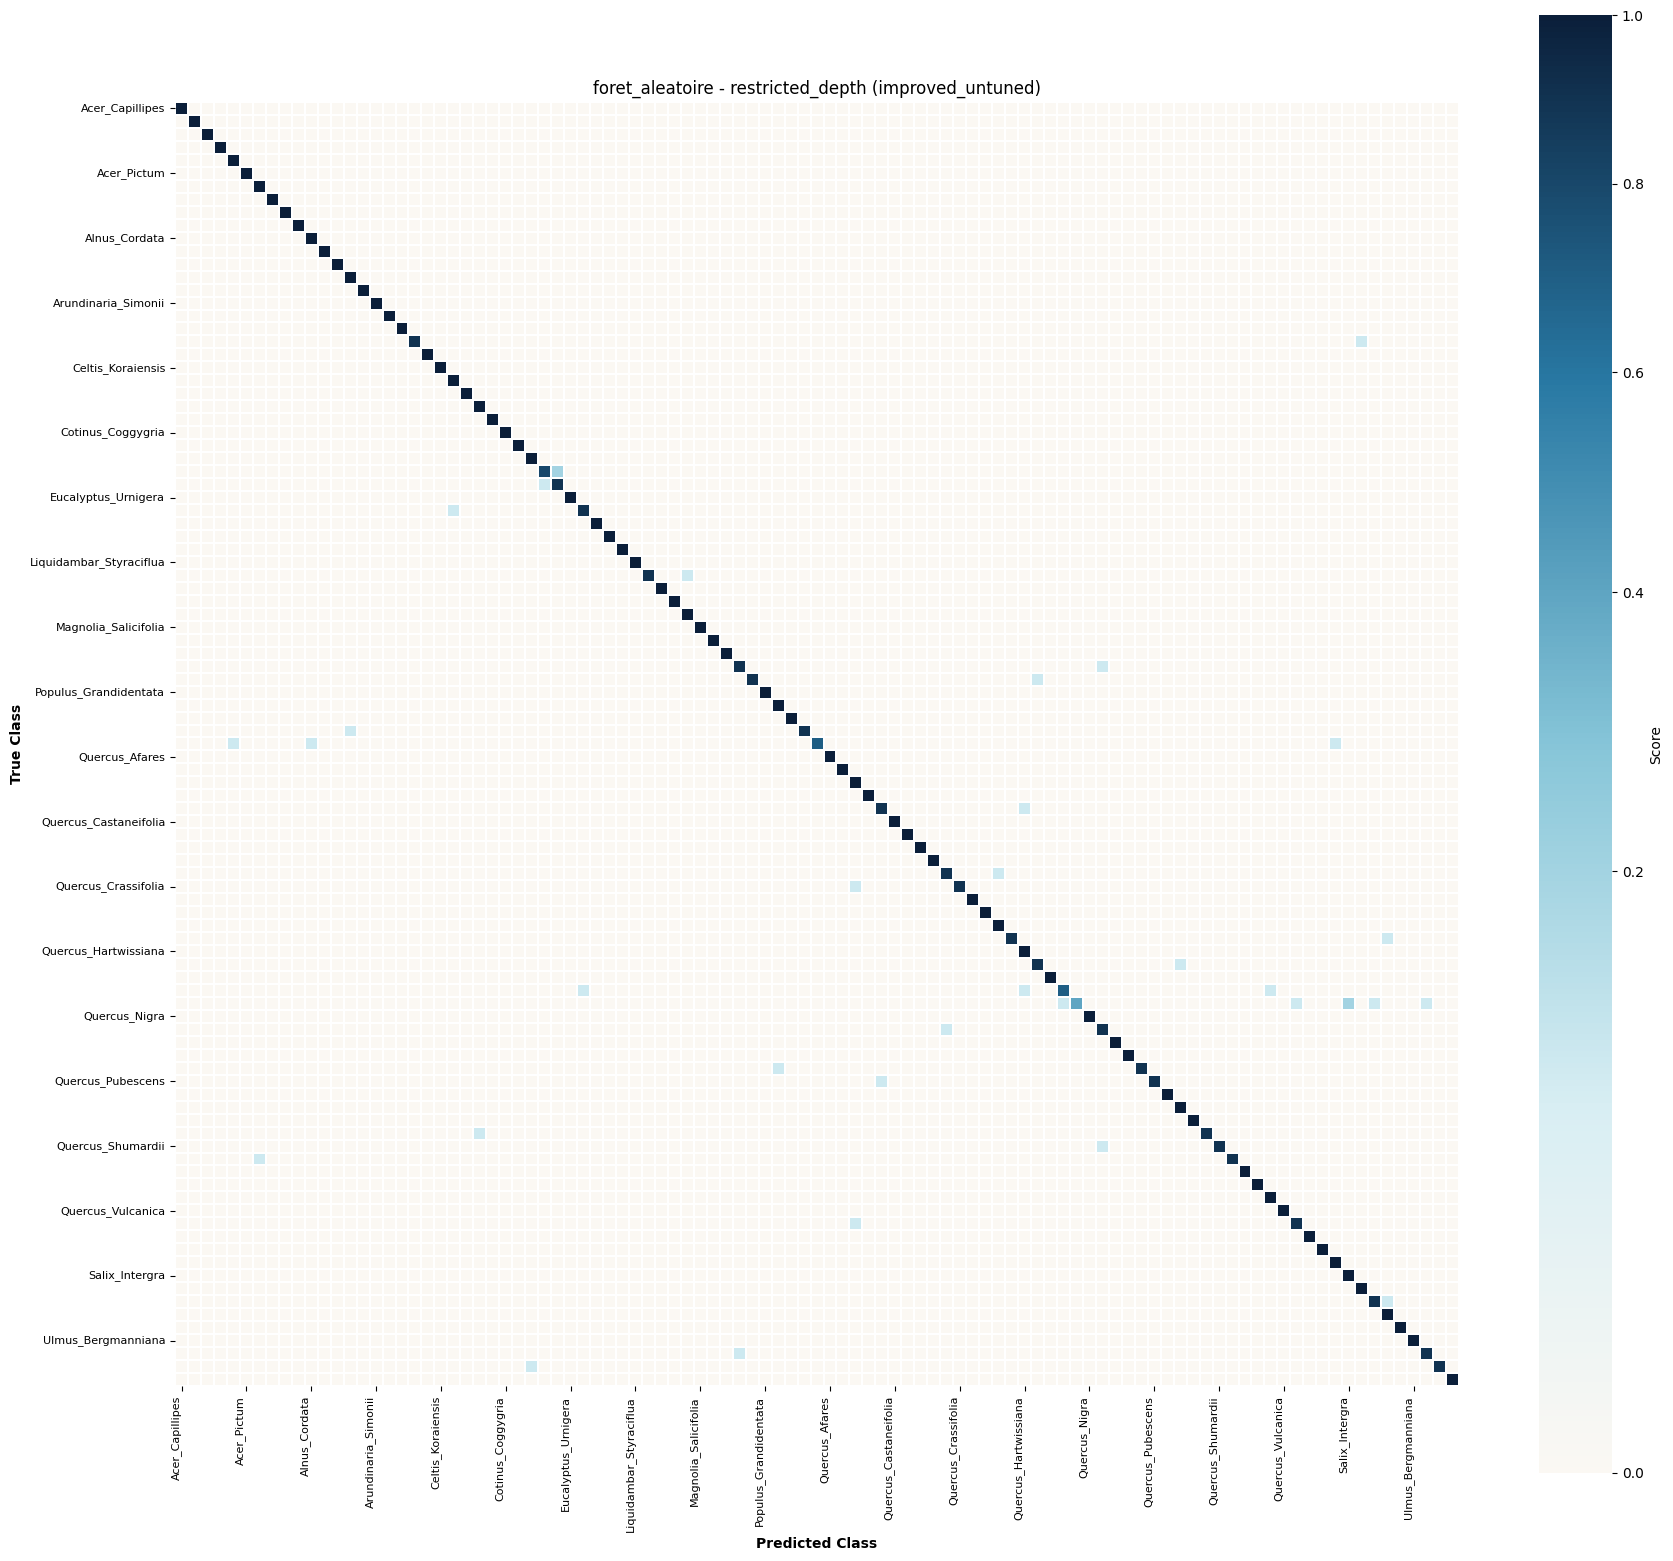

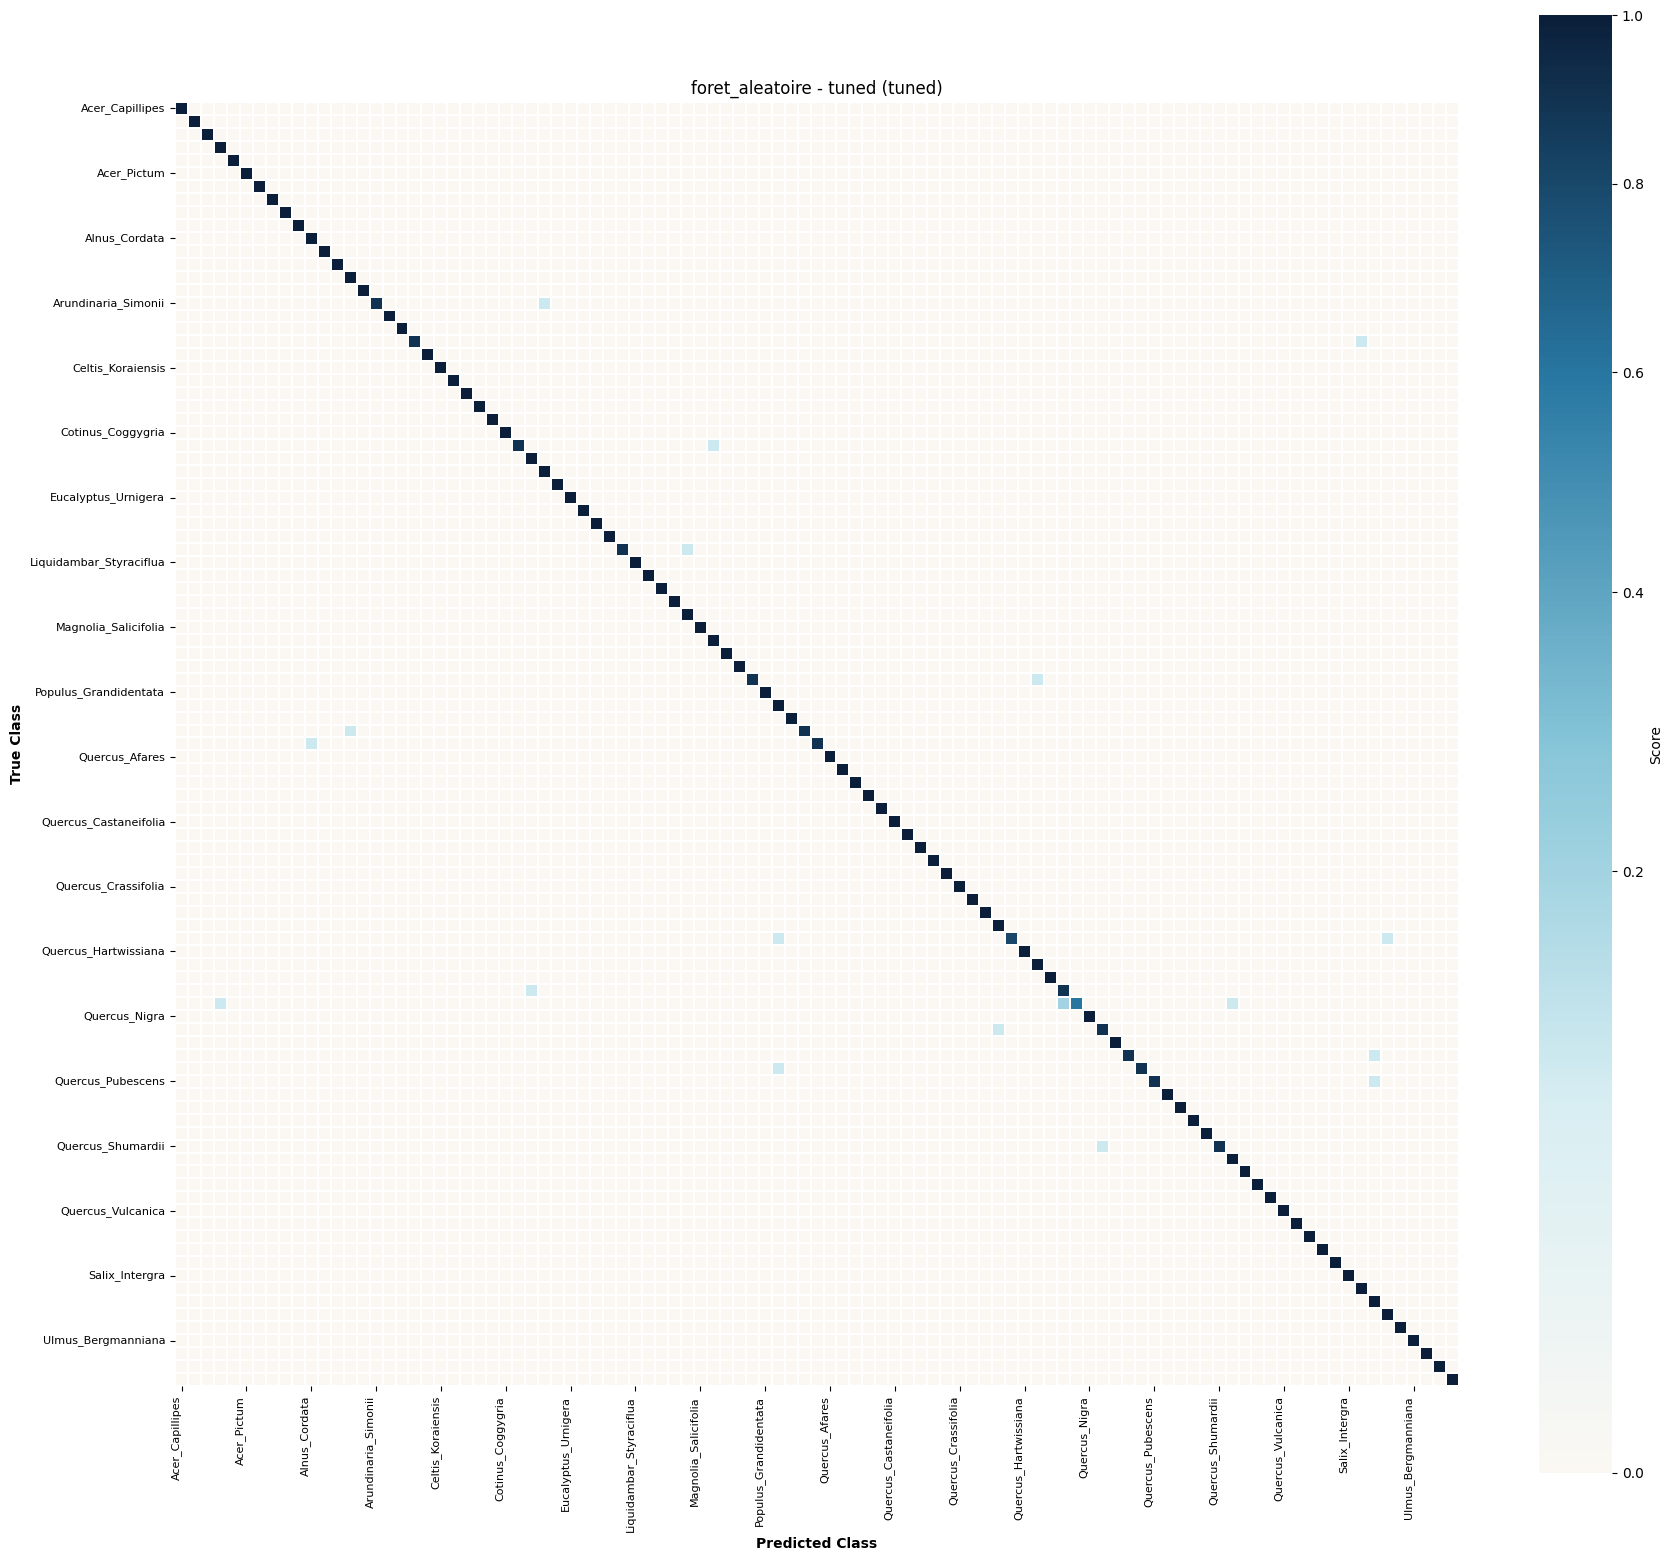

### mlp

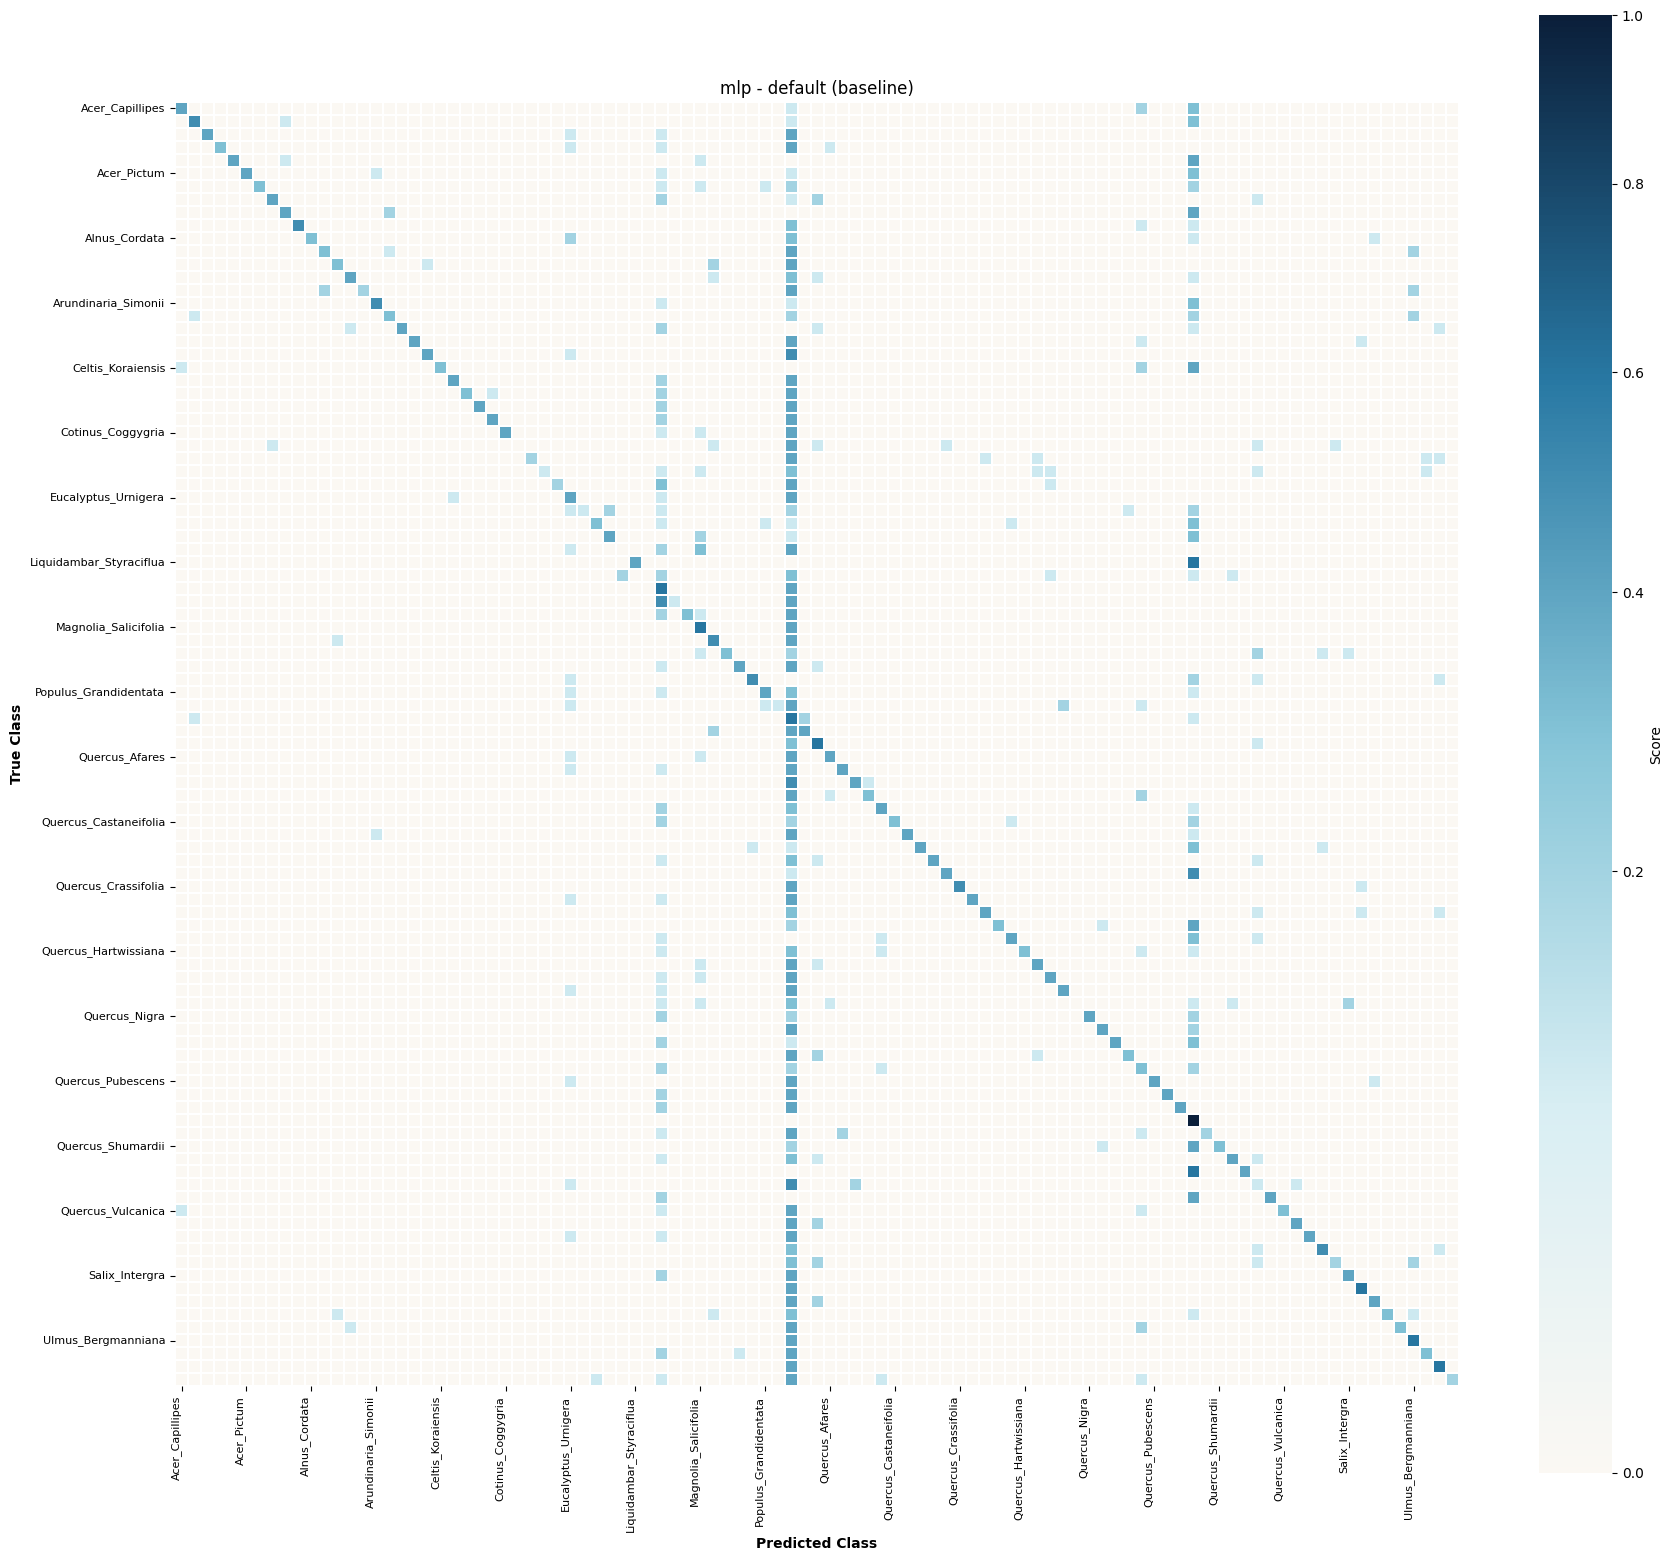

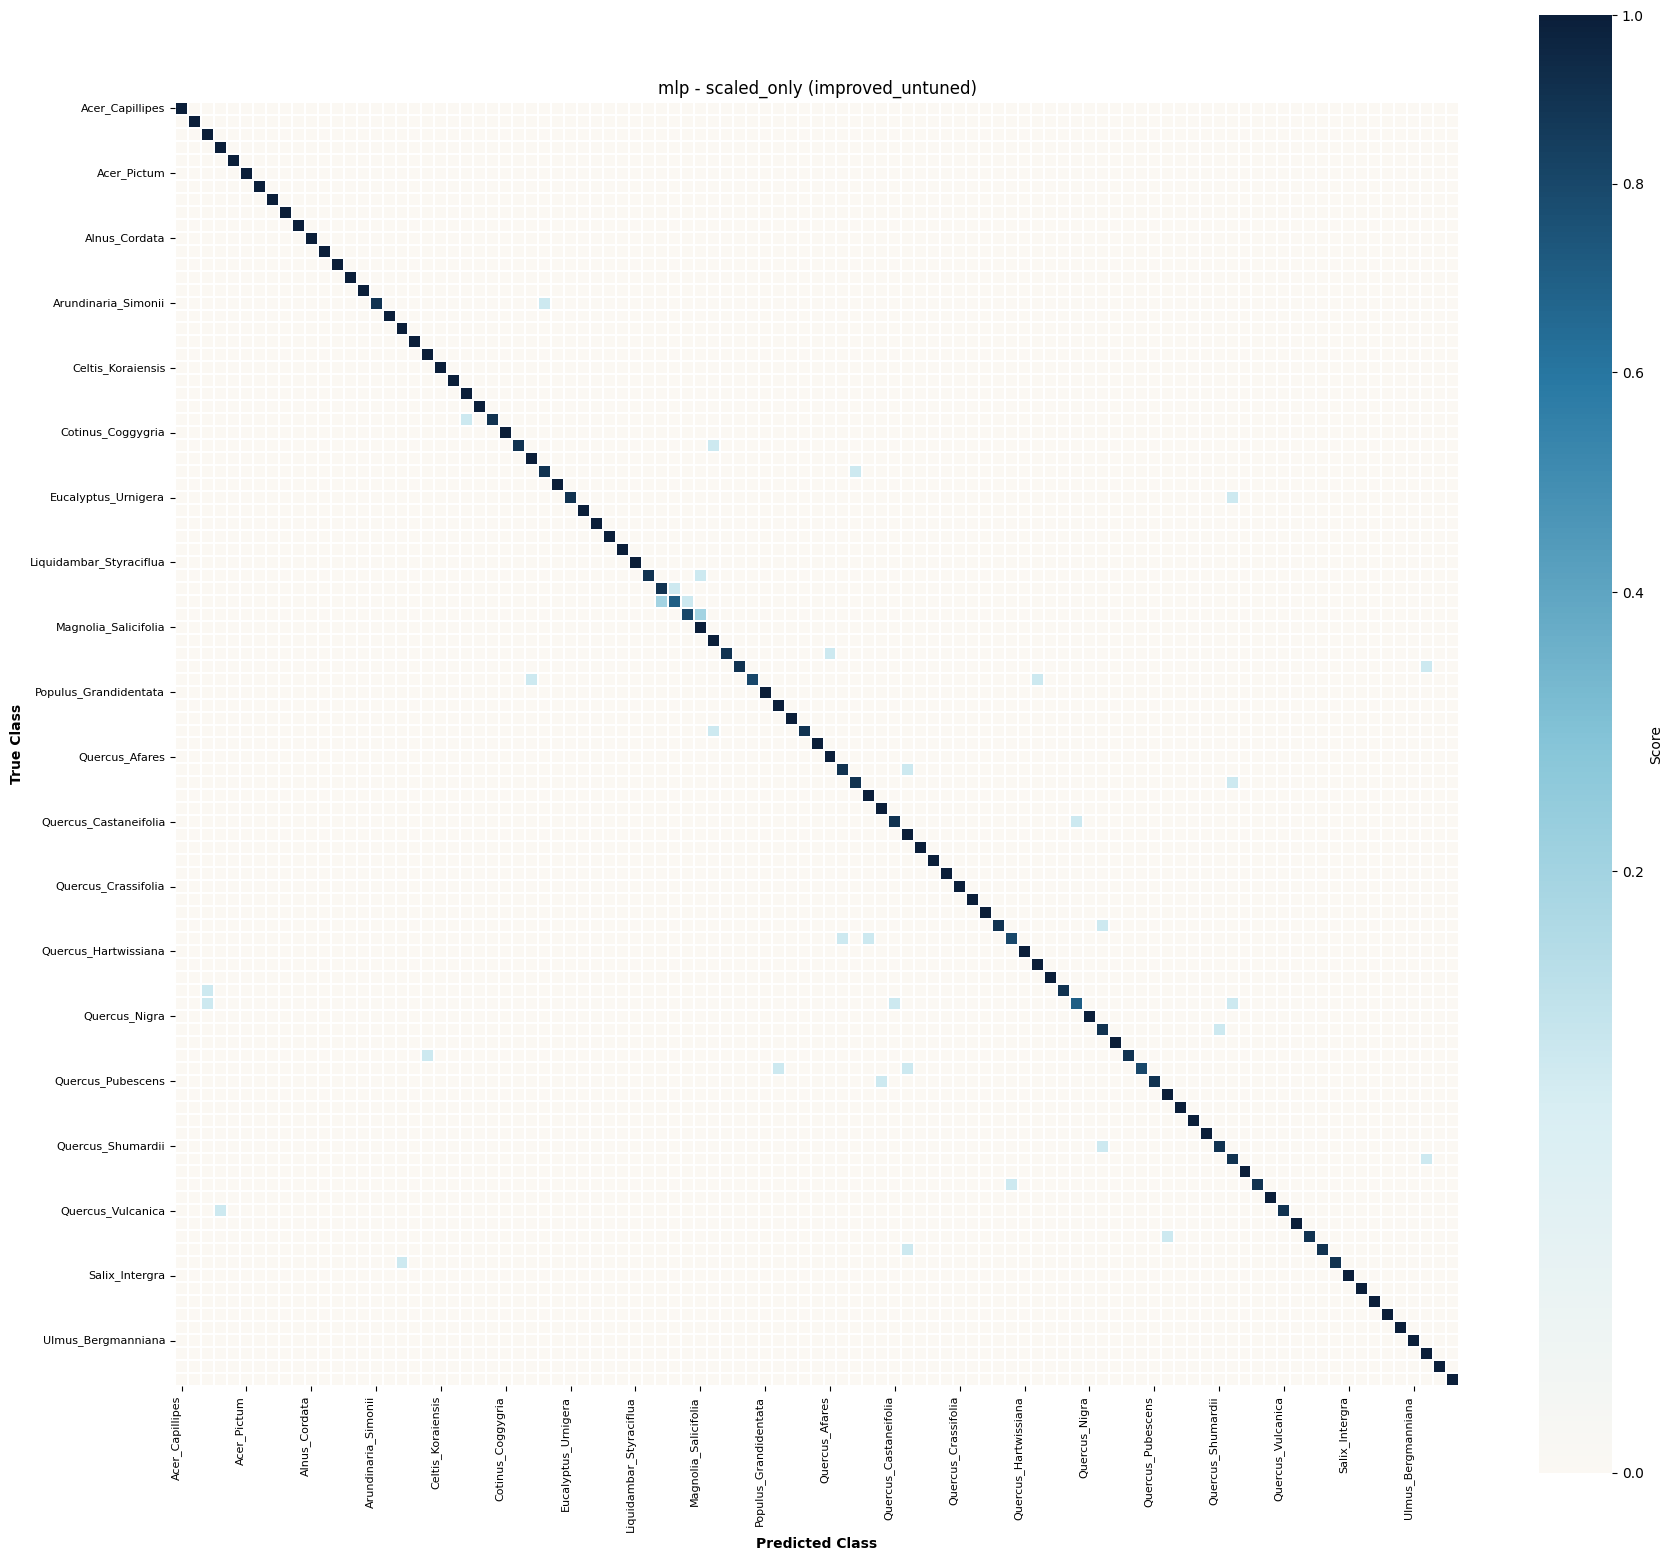

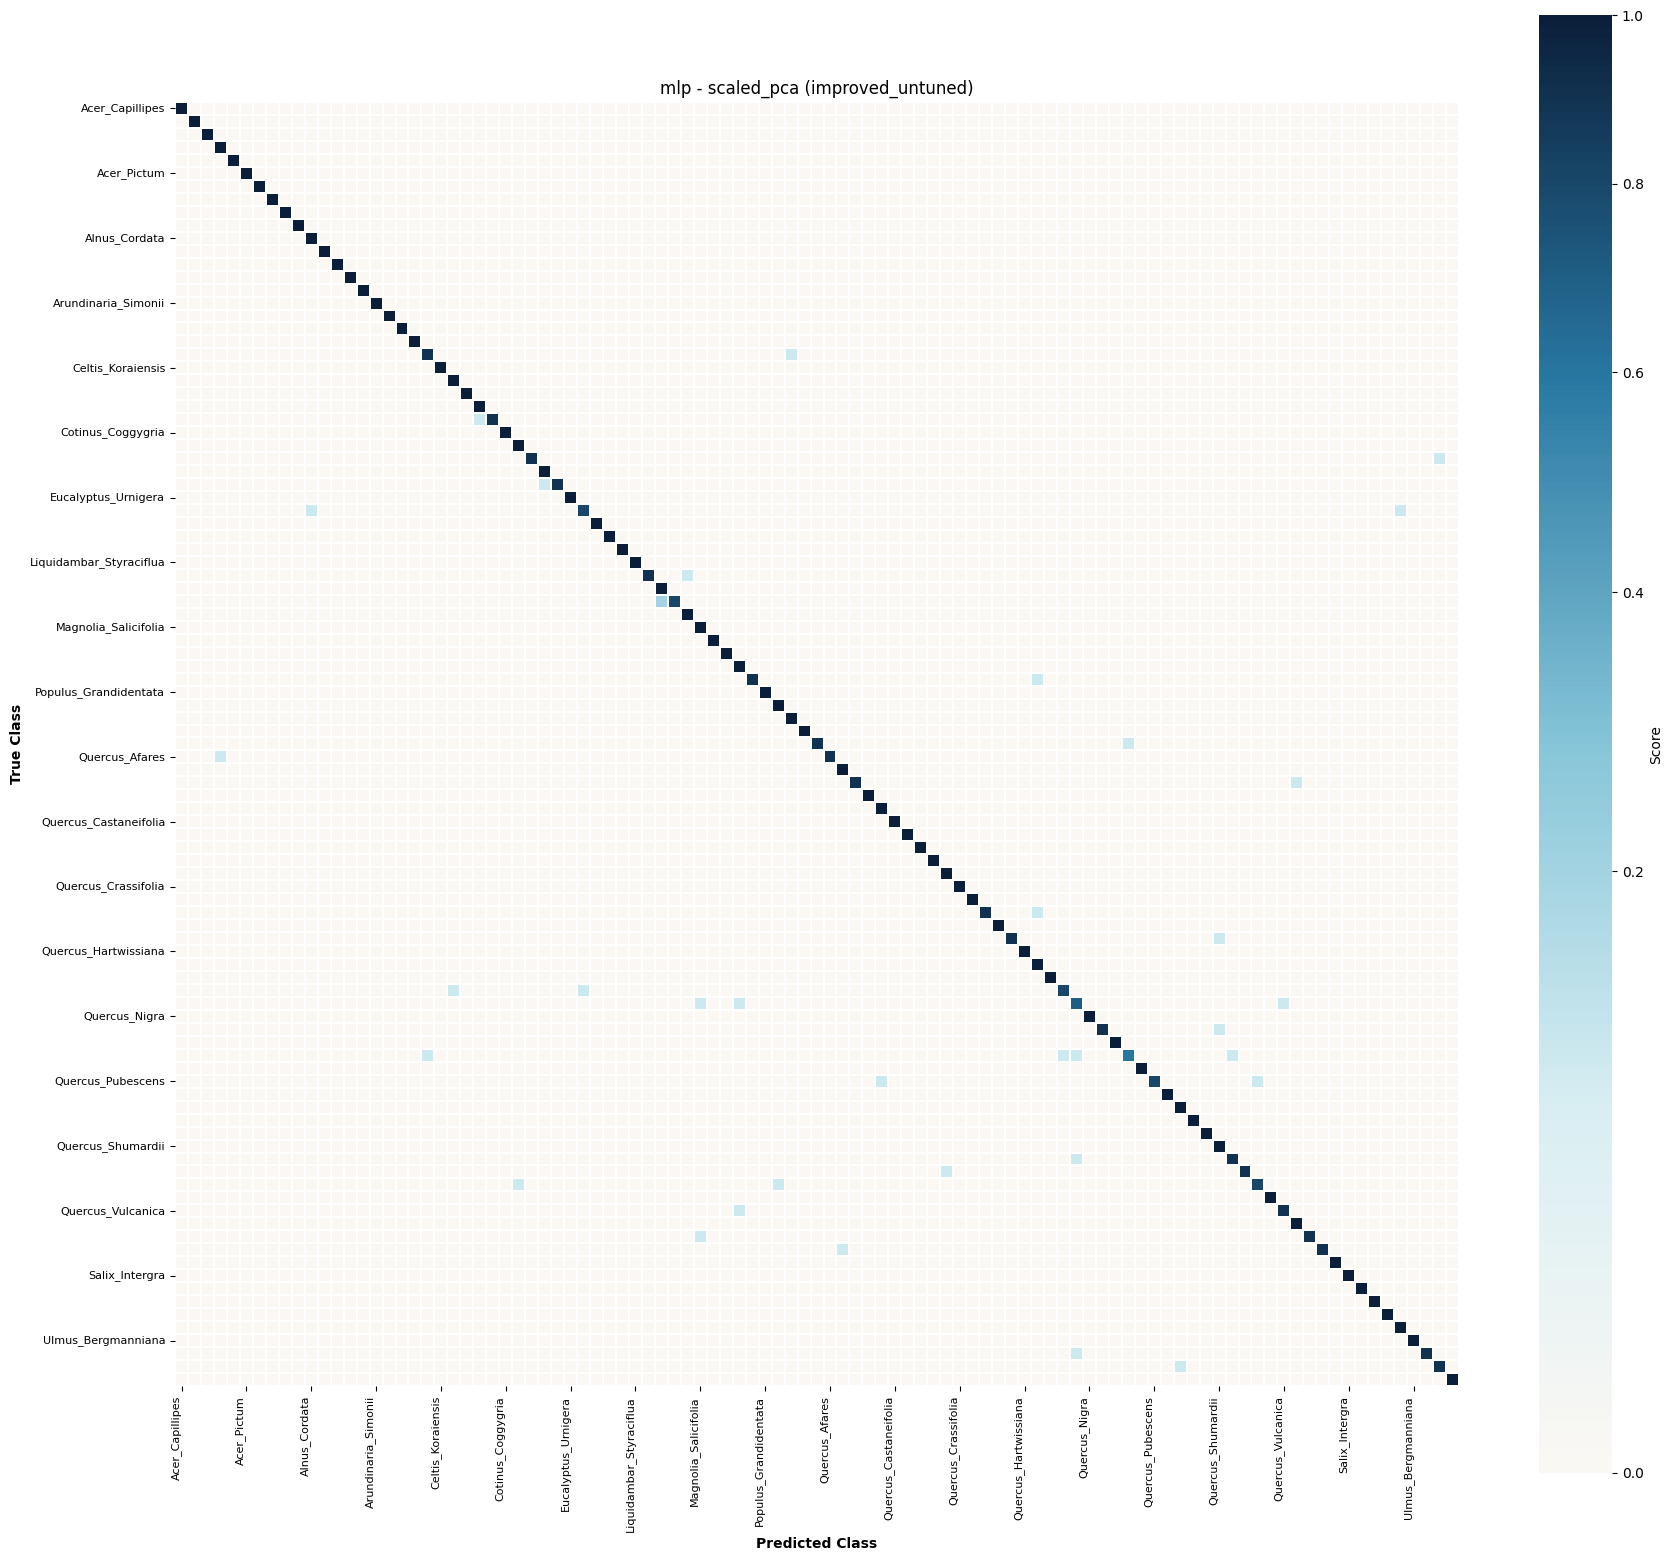

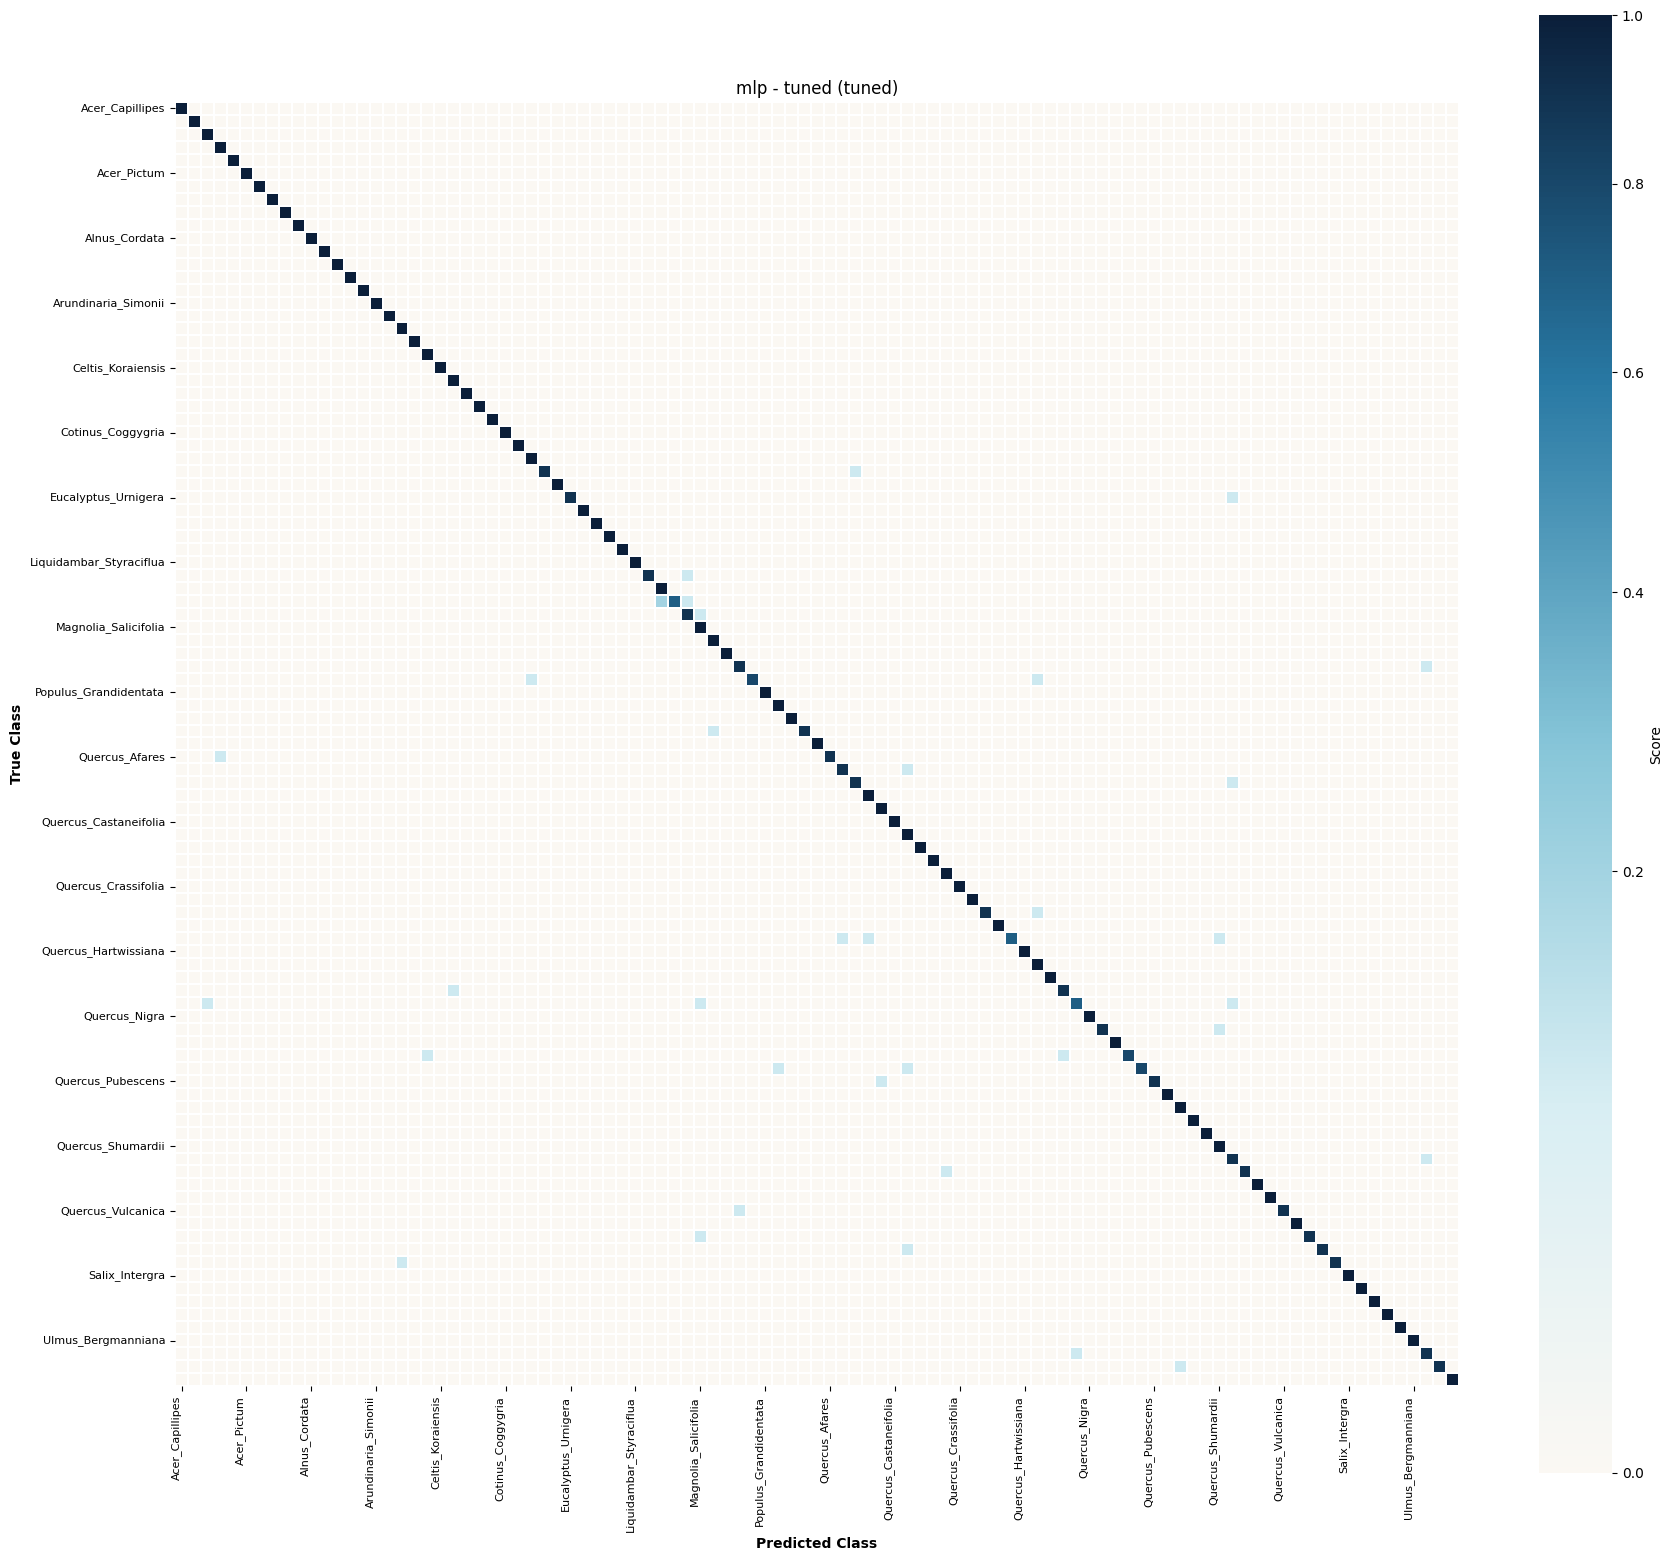

### perceptron

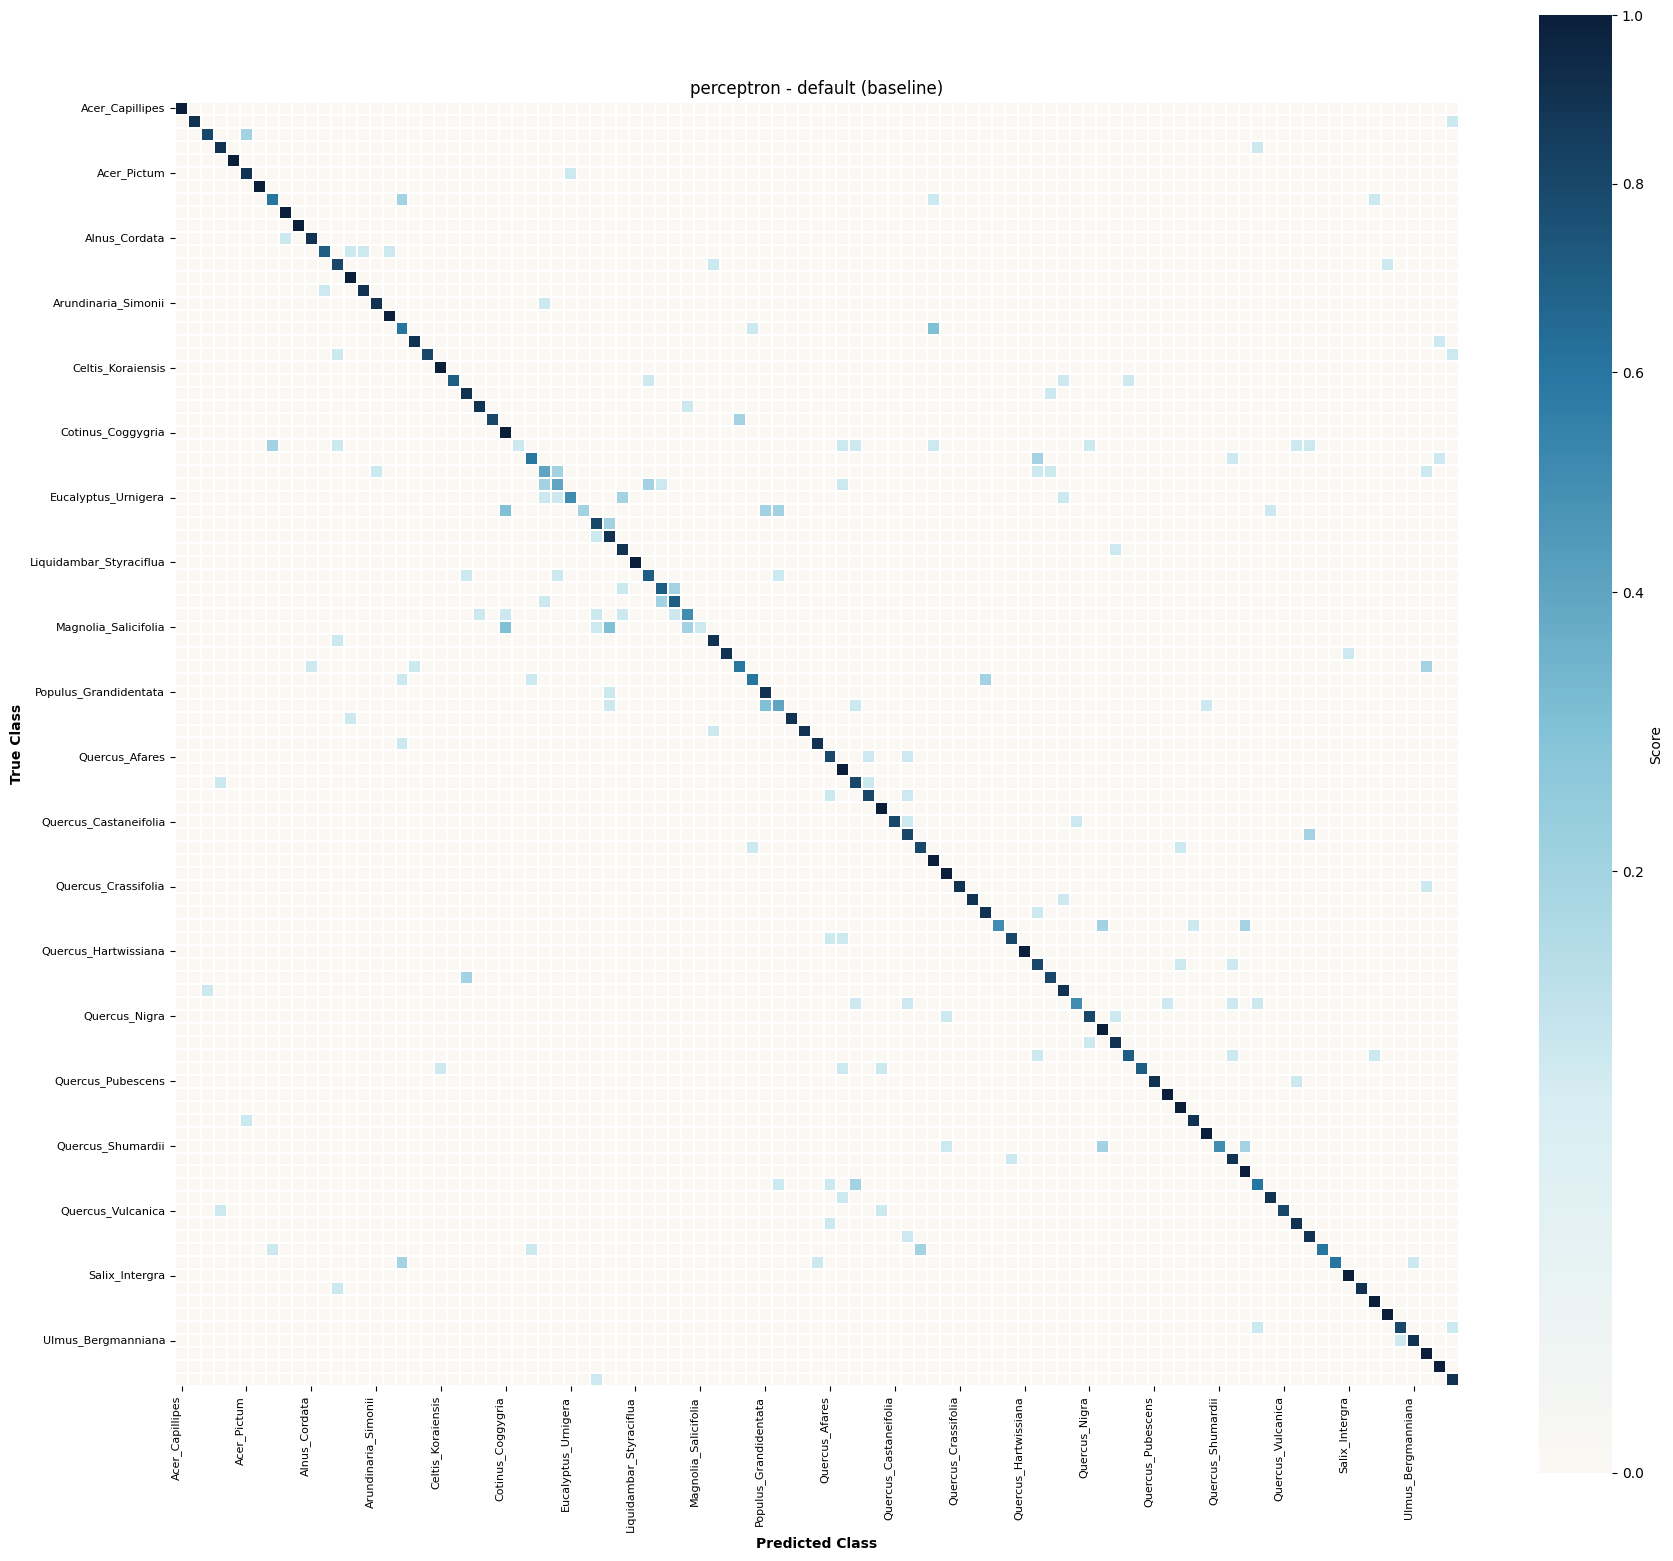

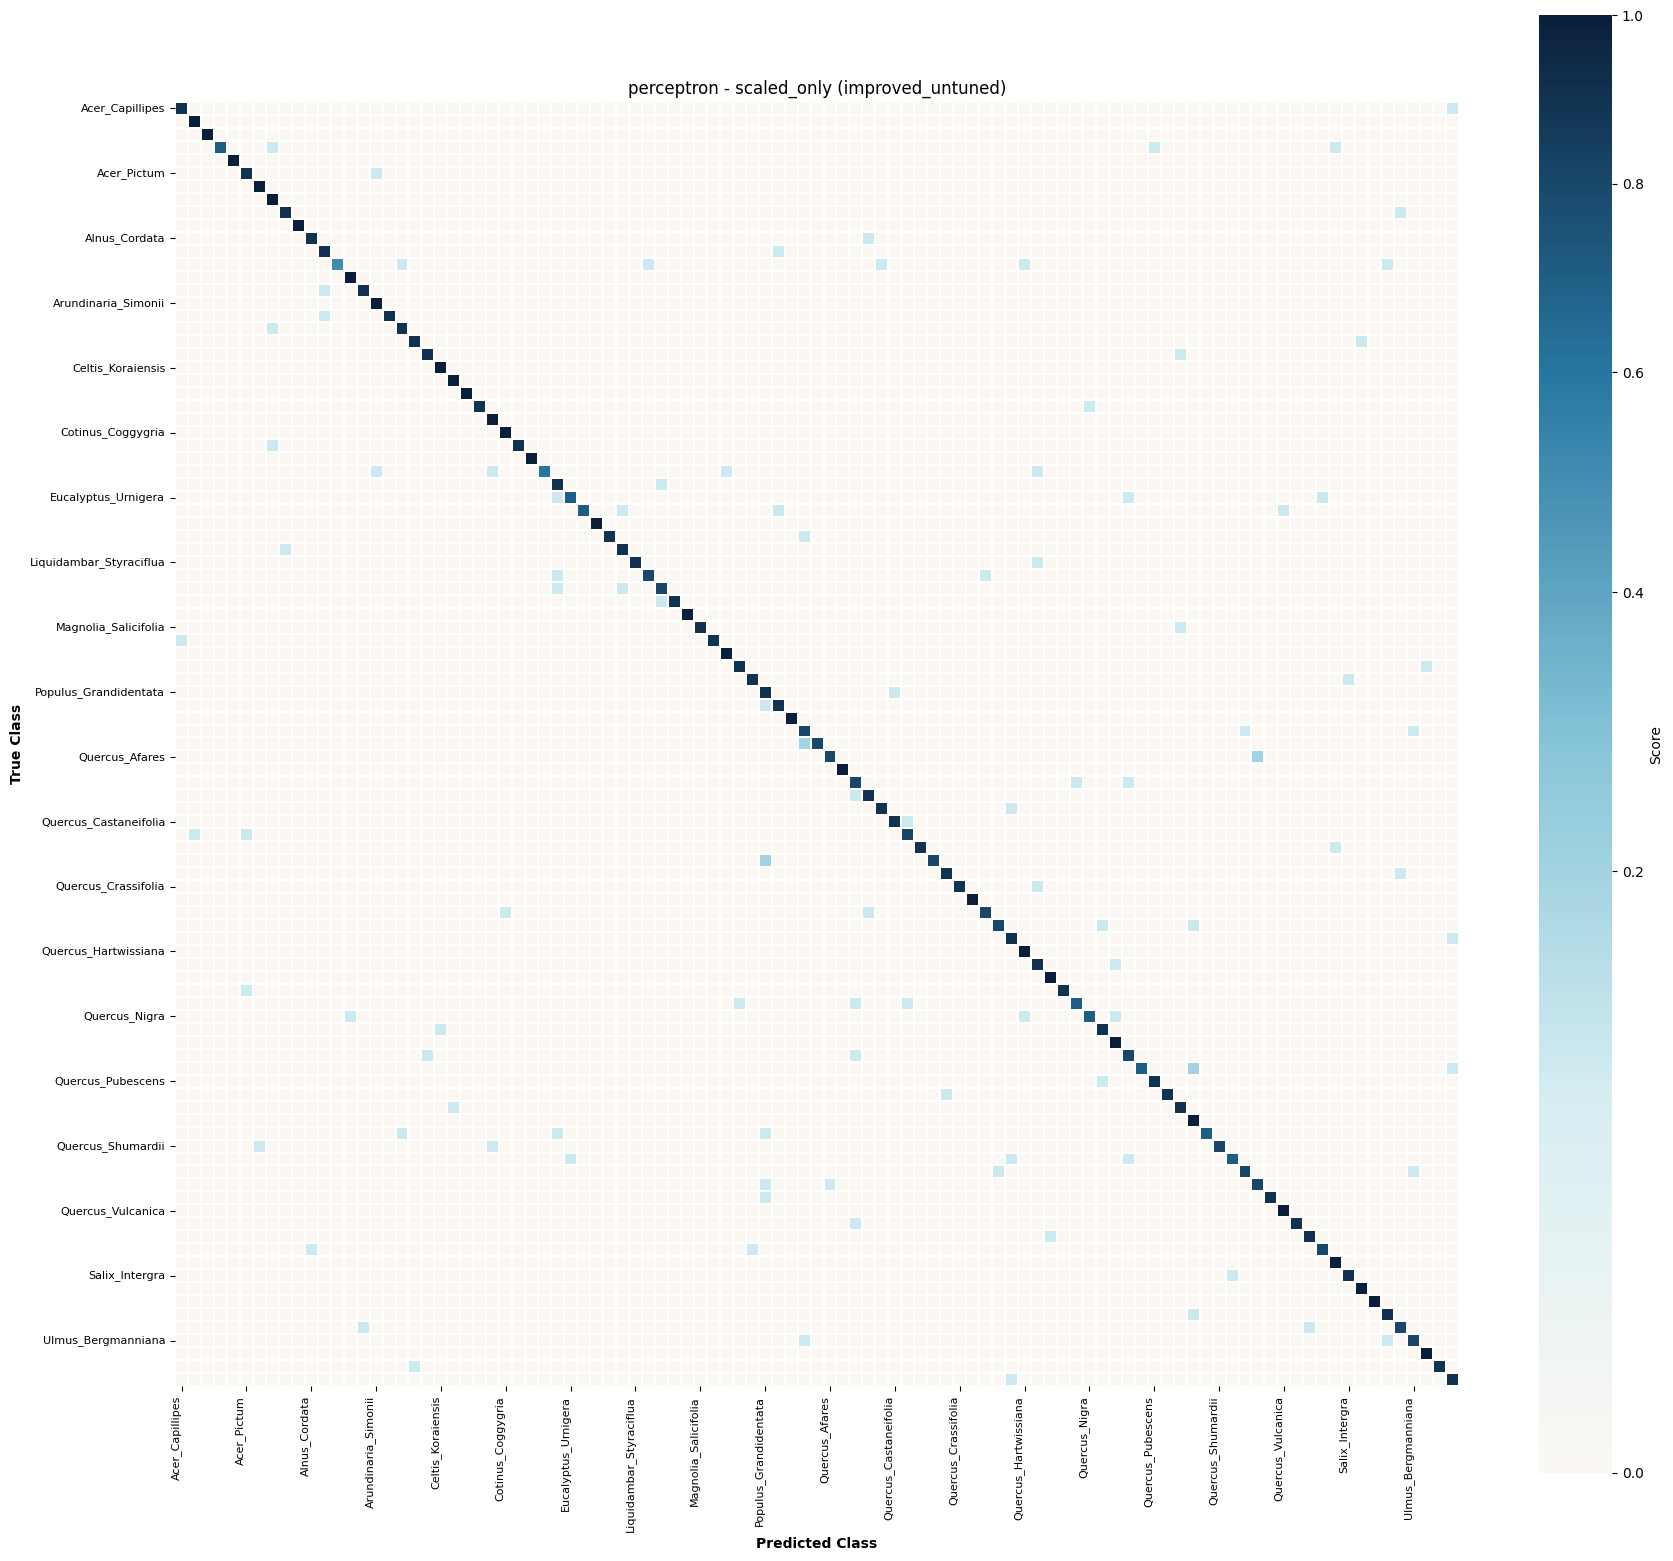

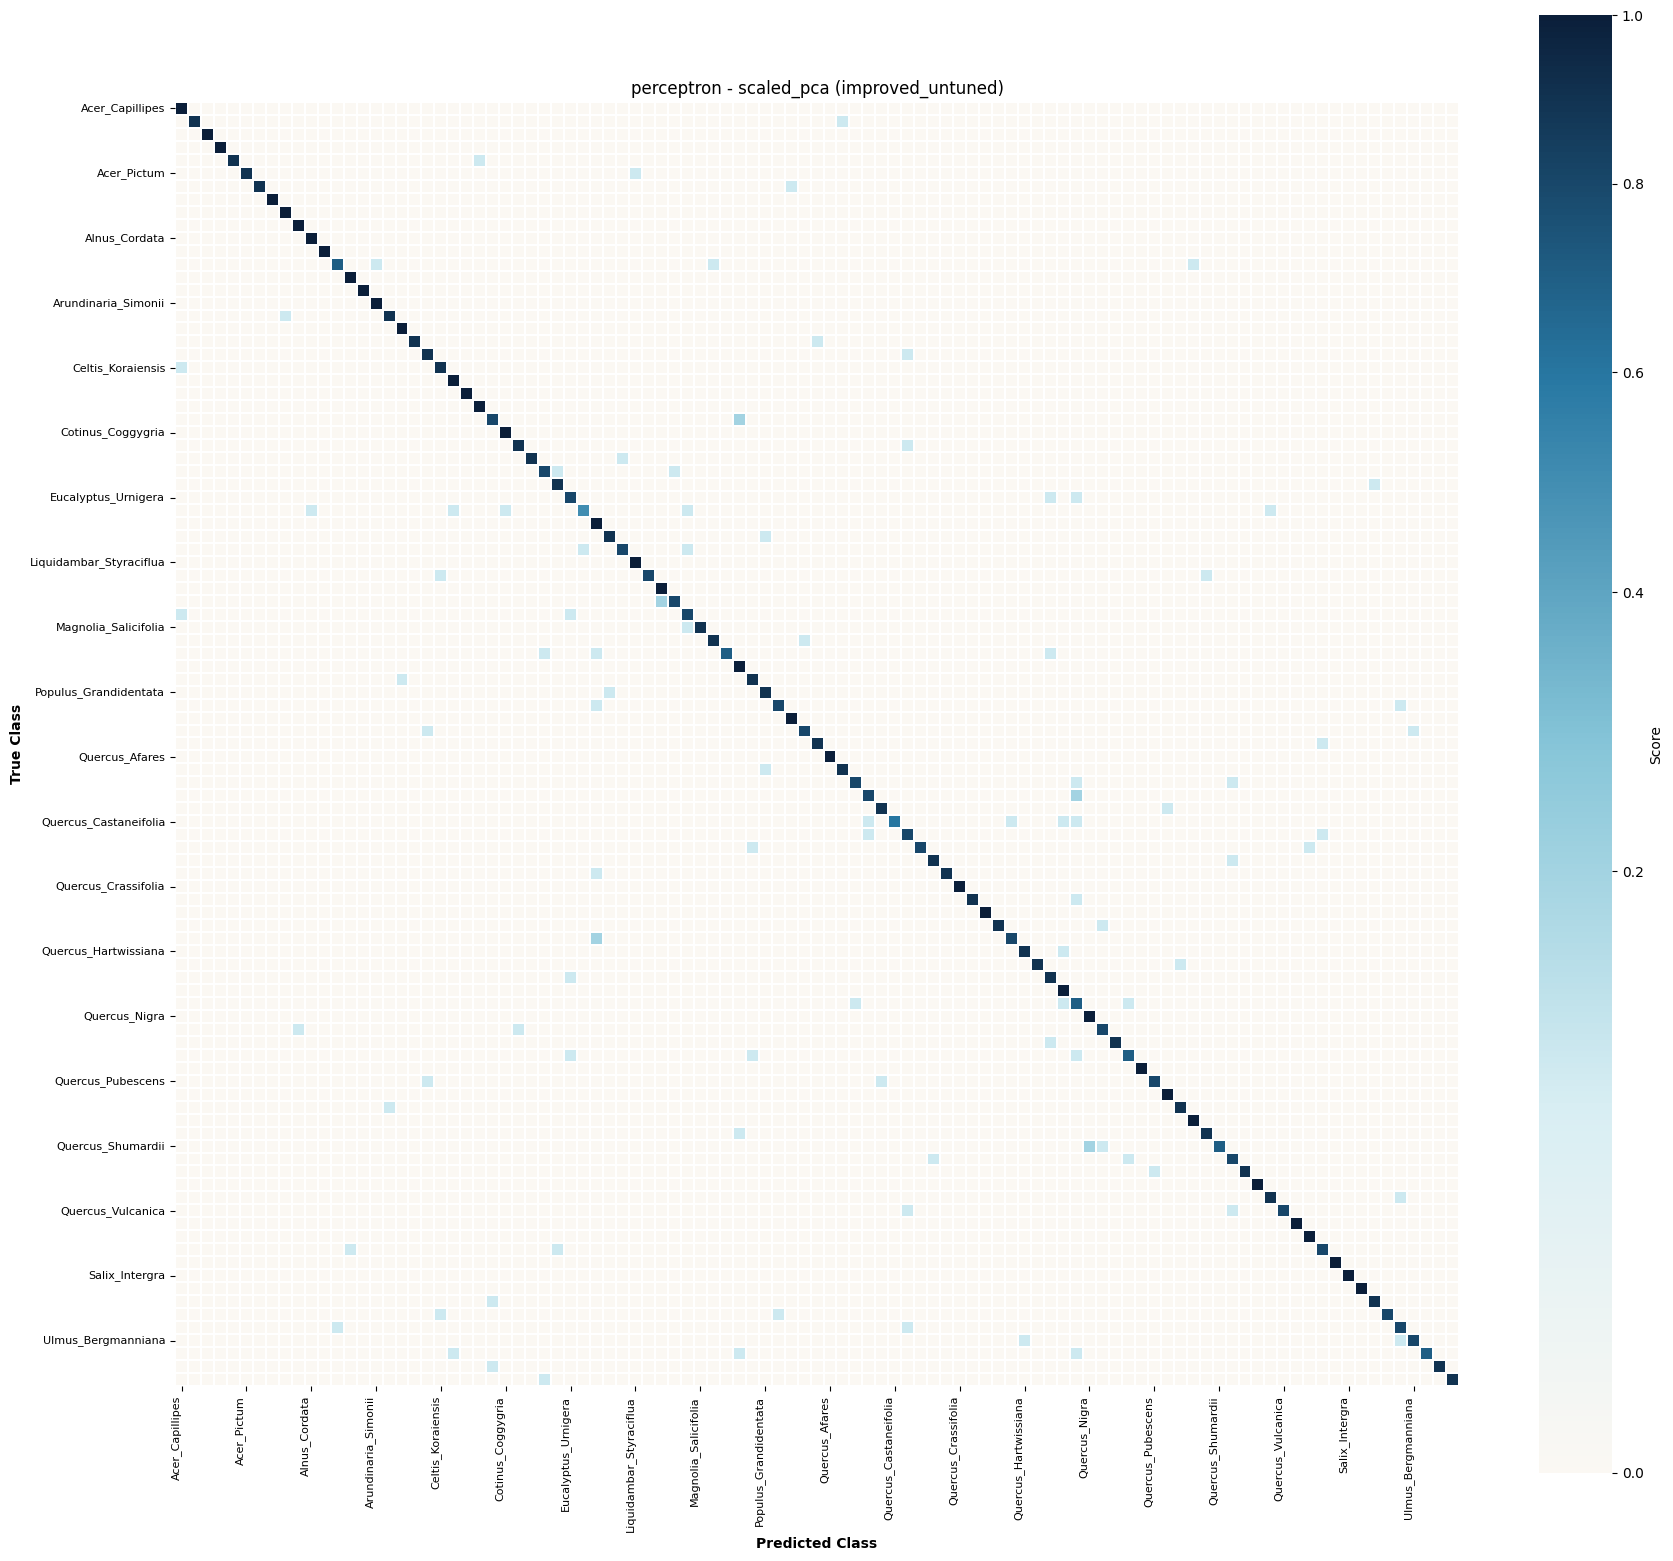

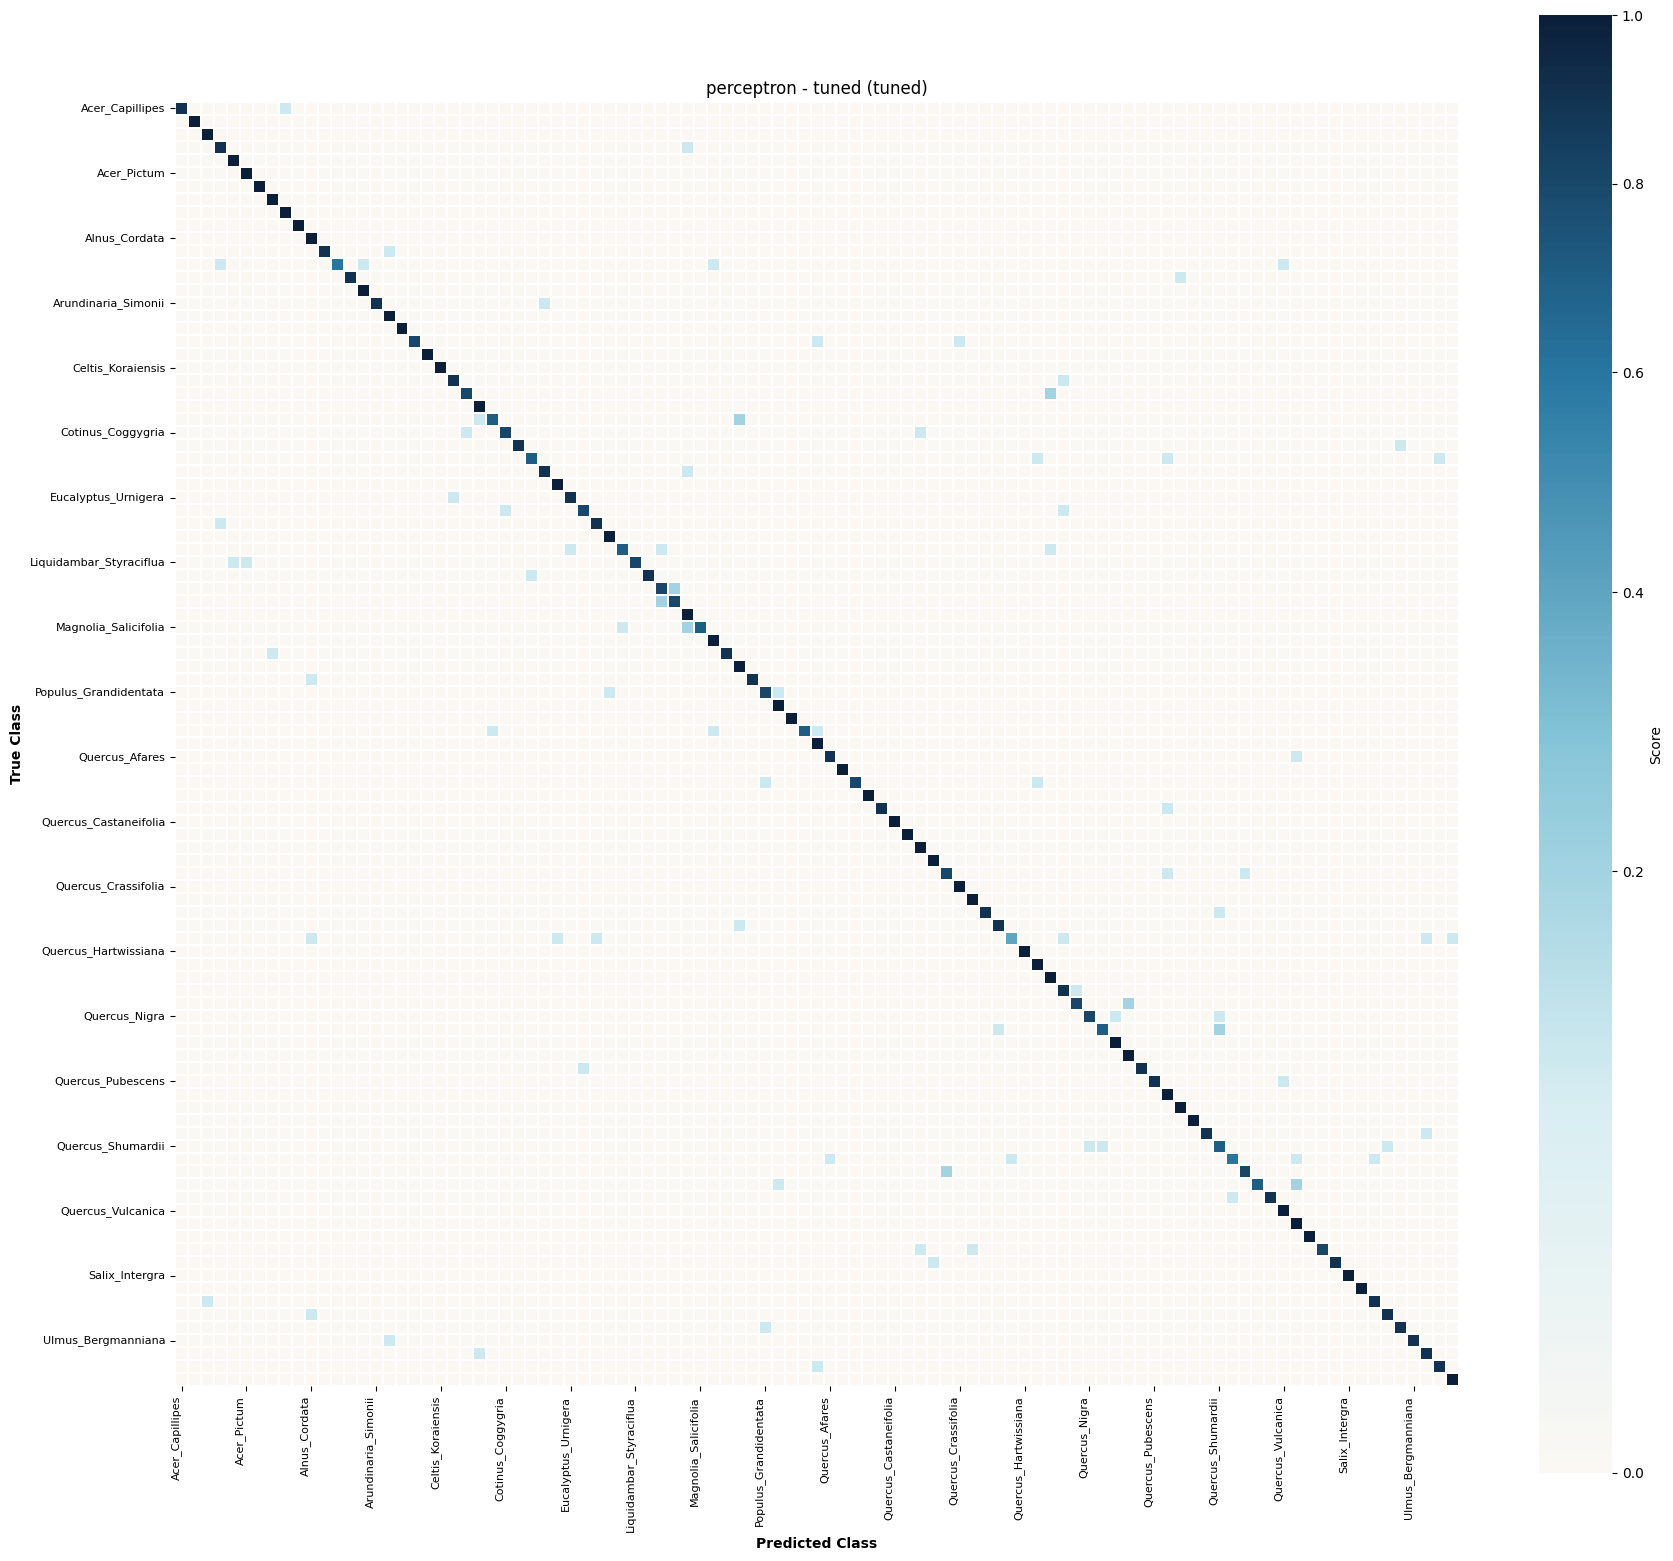

### regression_logistique

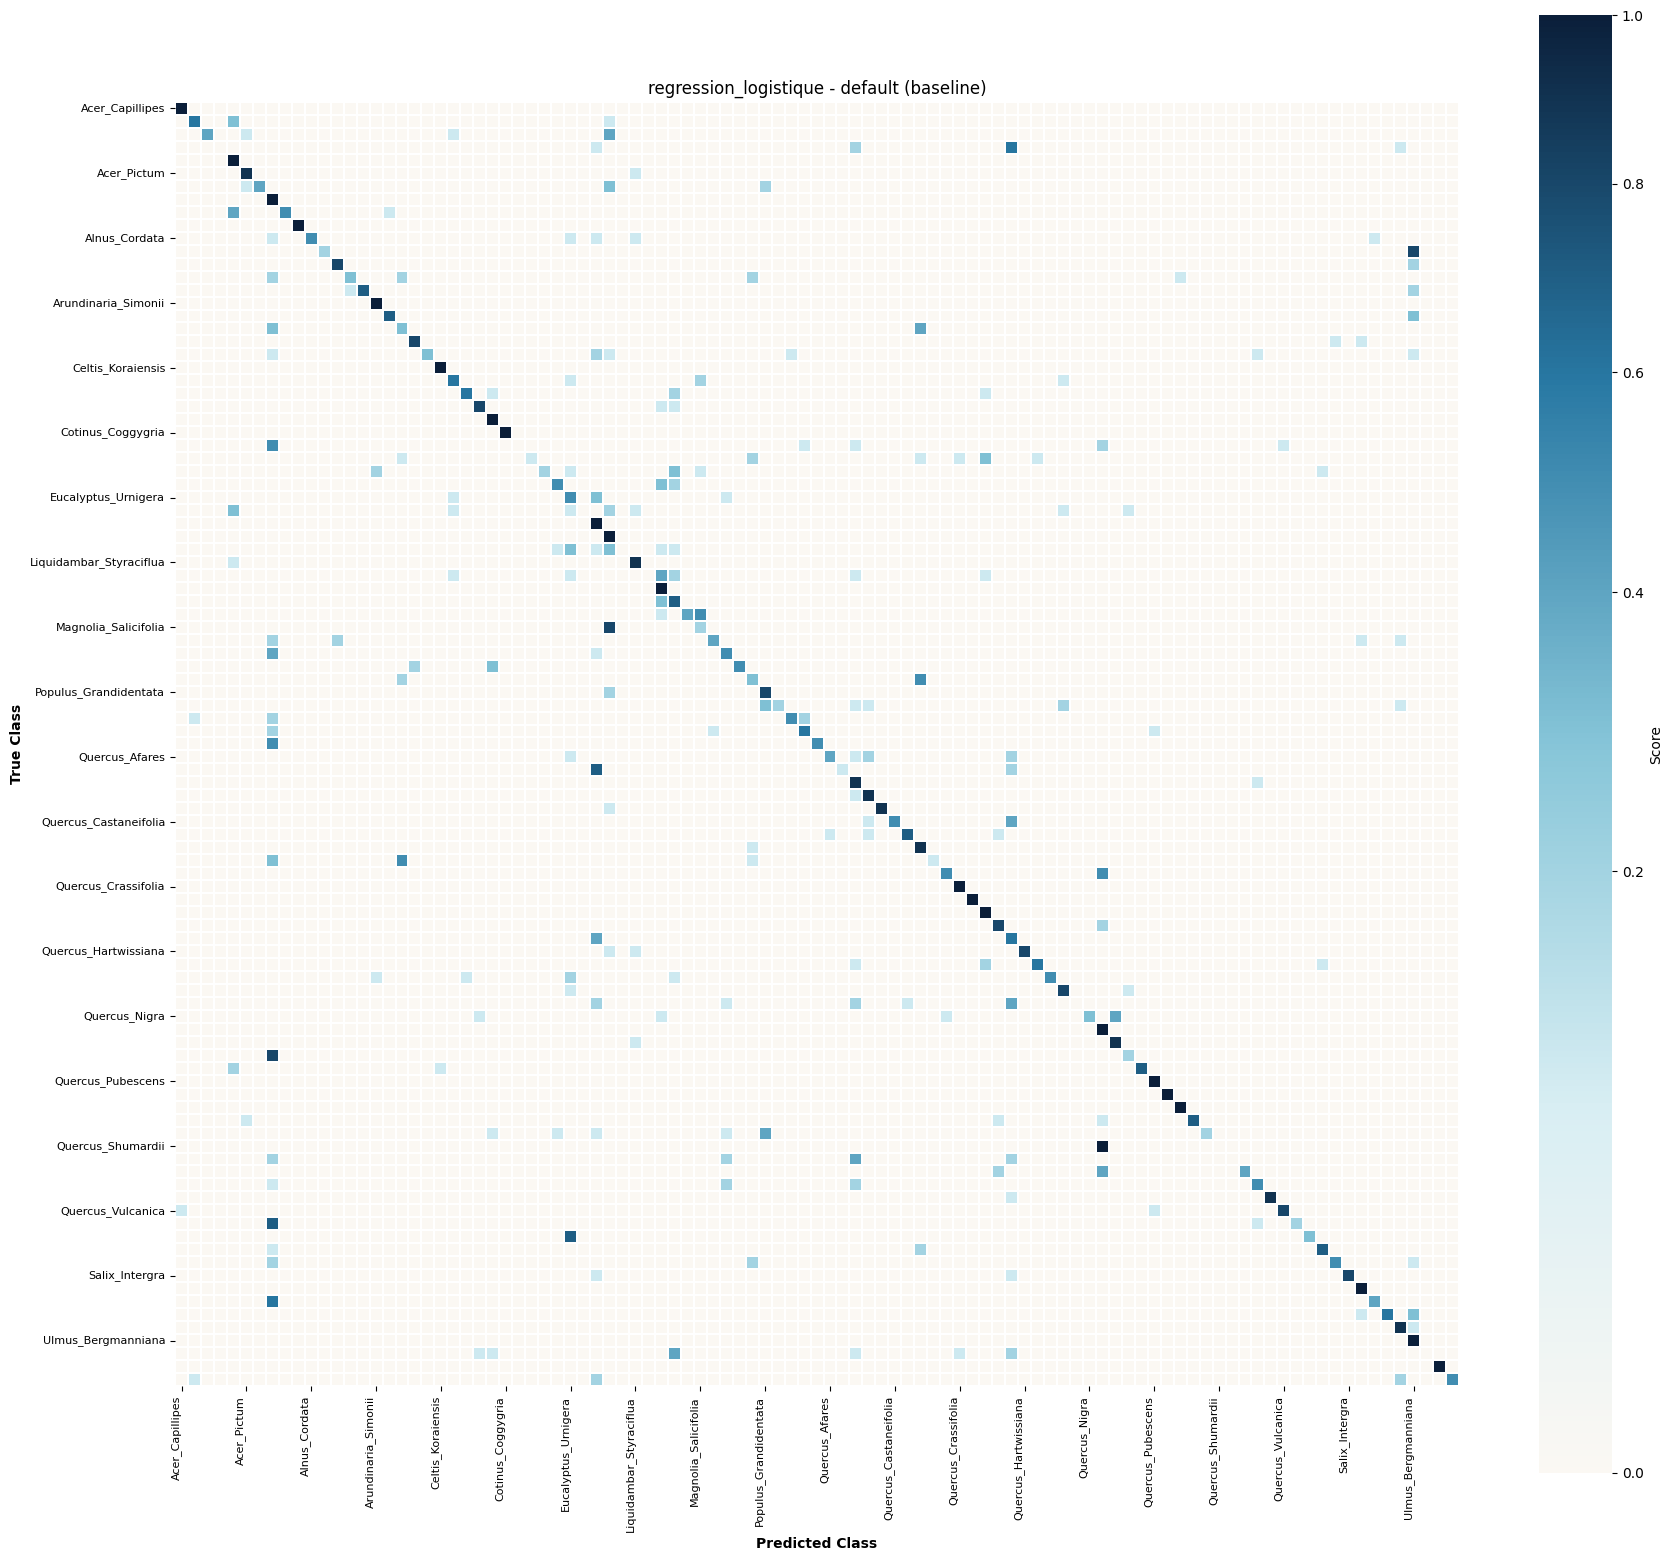

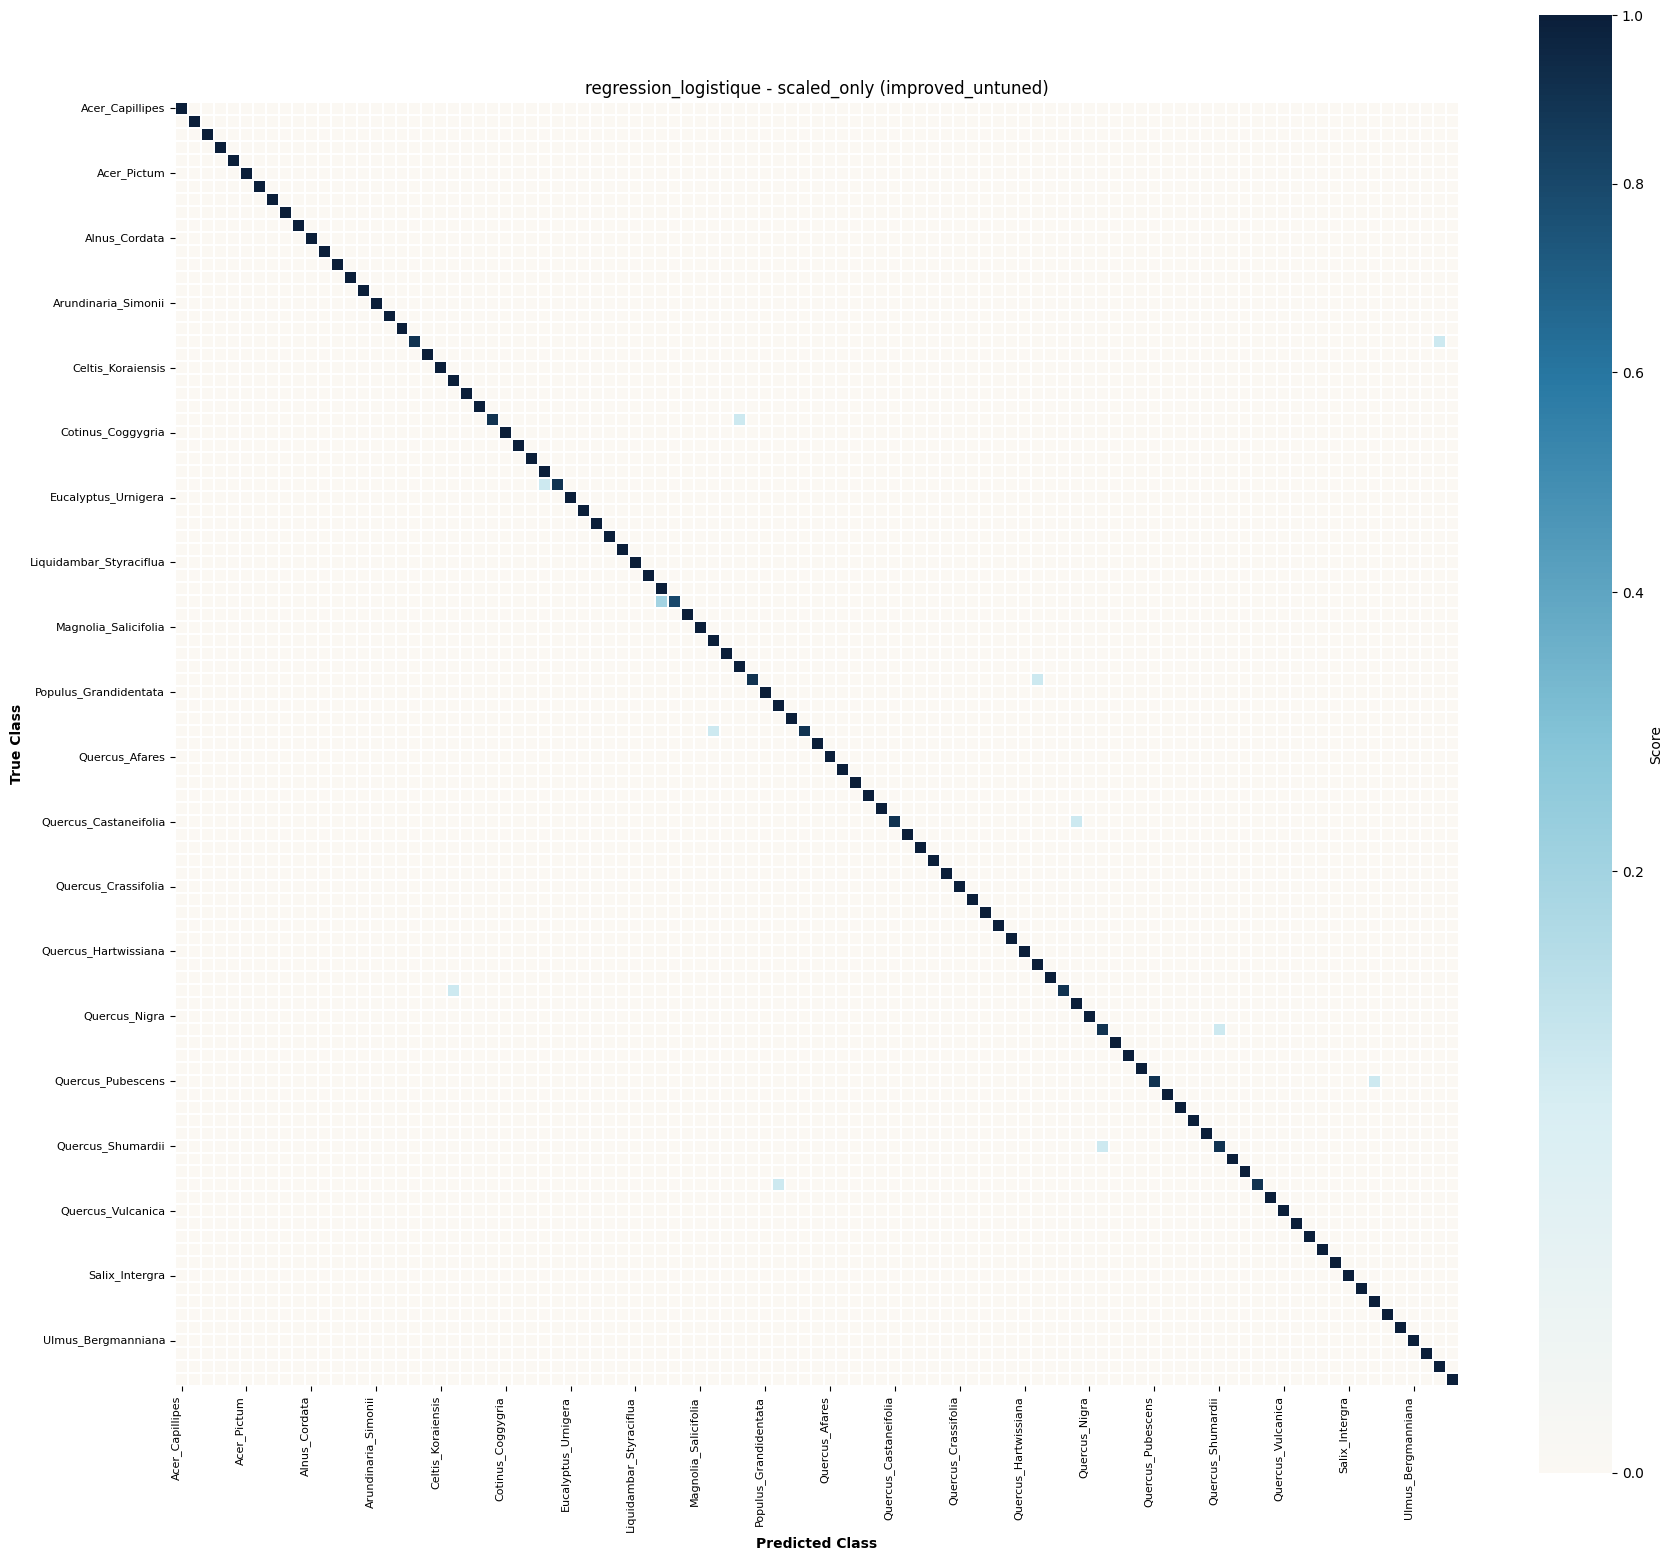

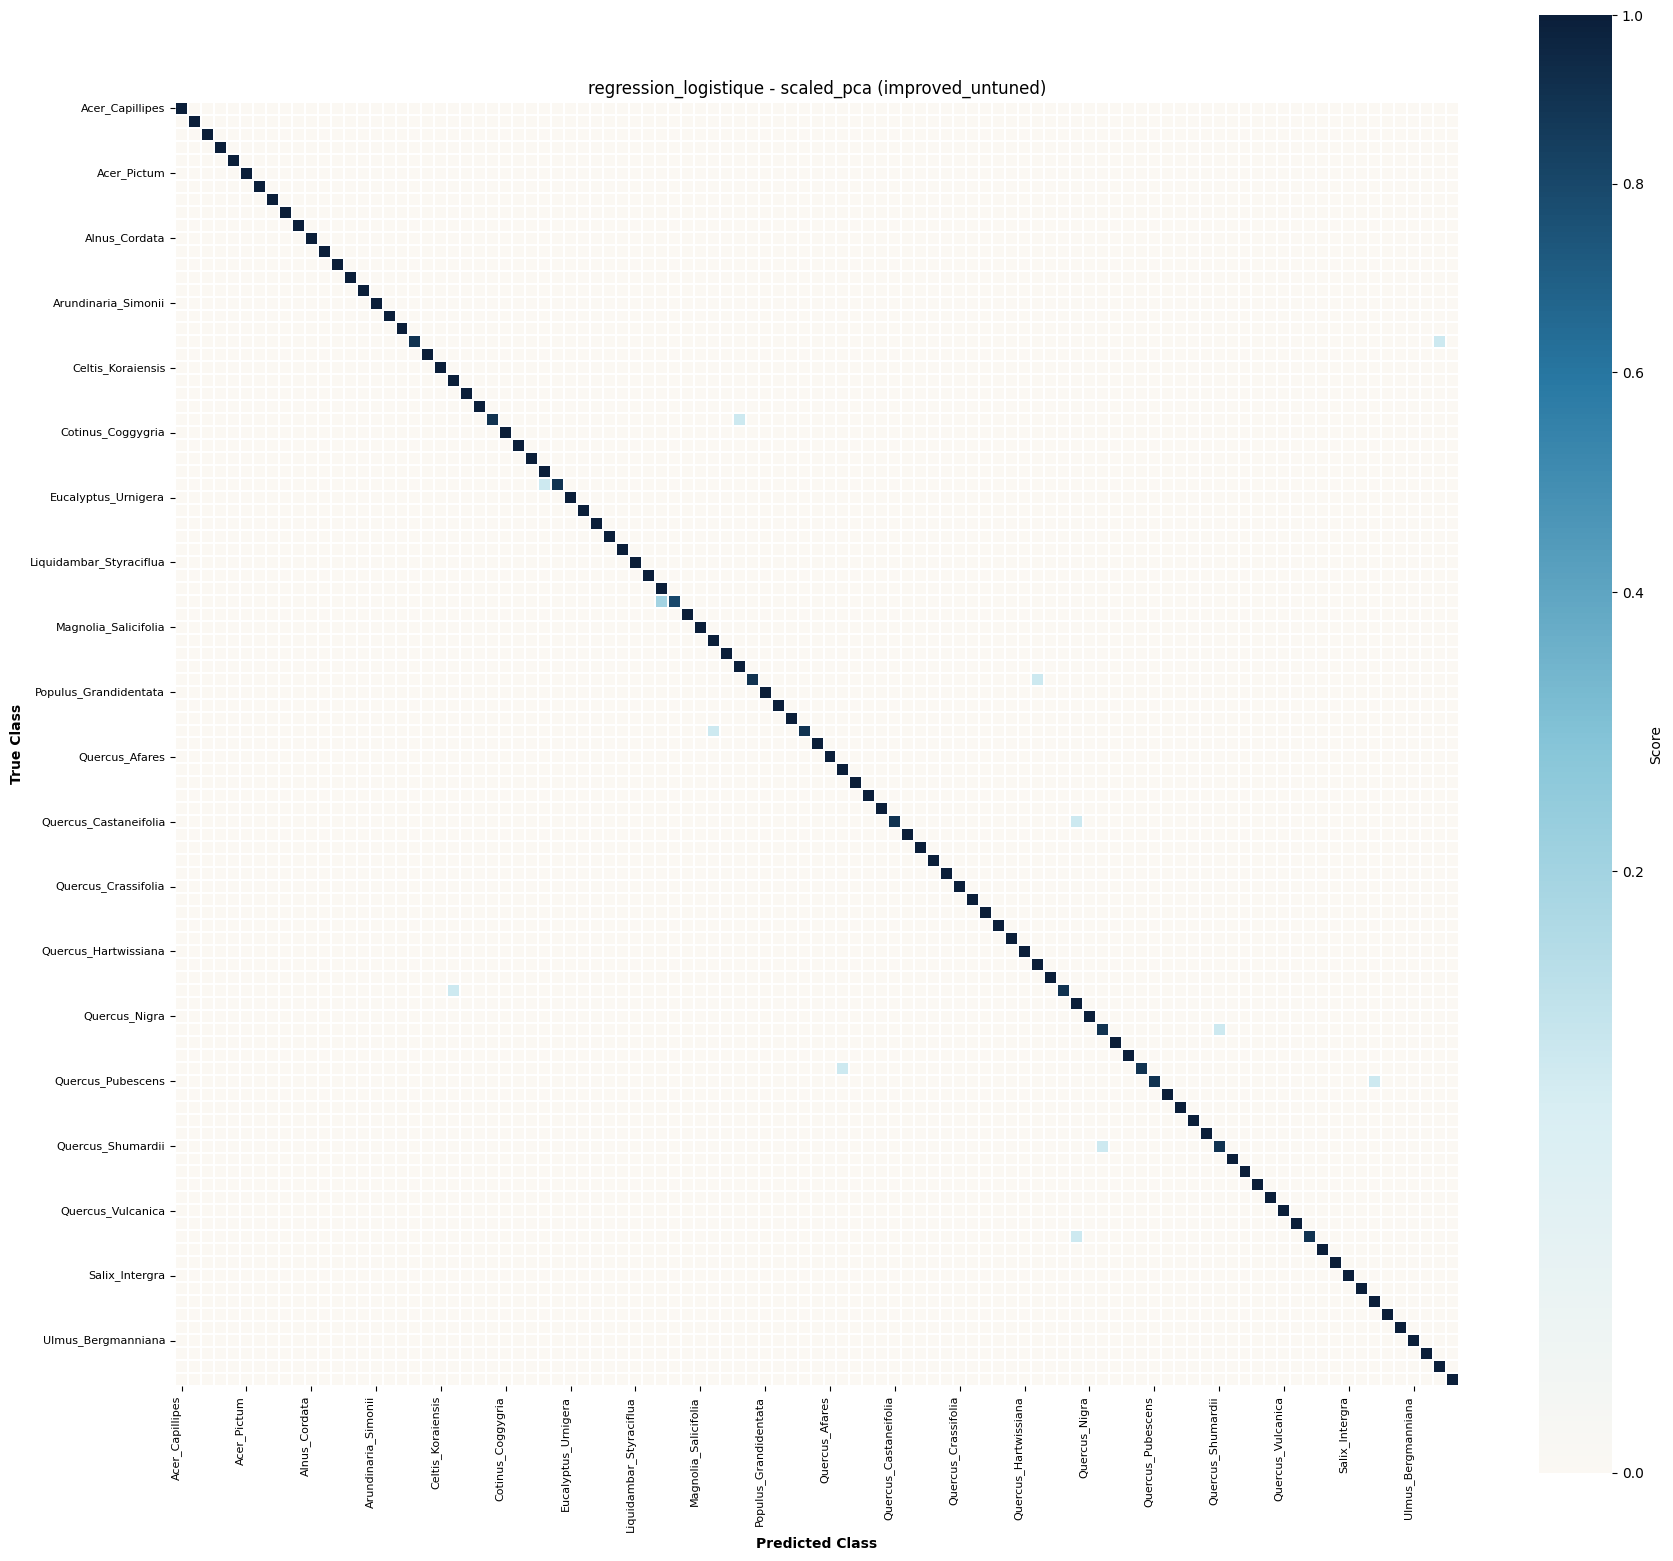

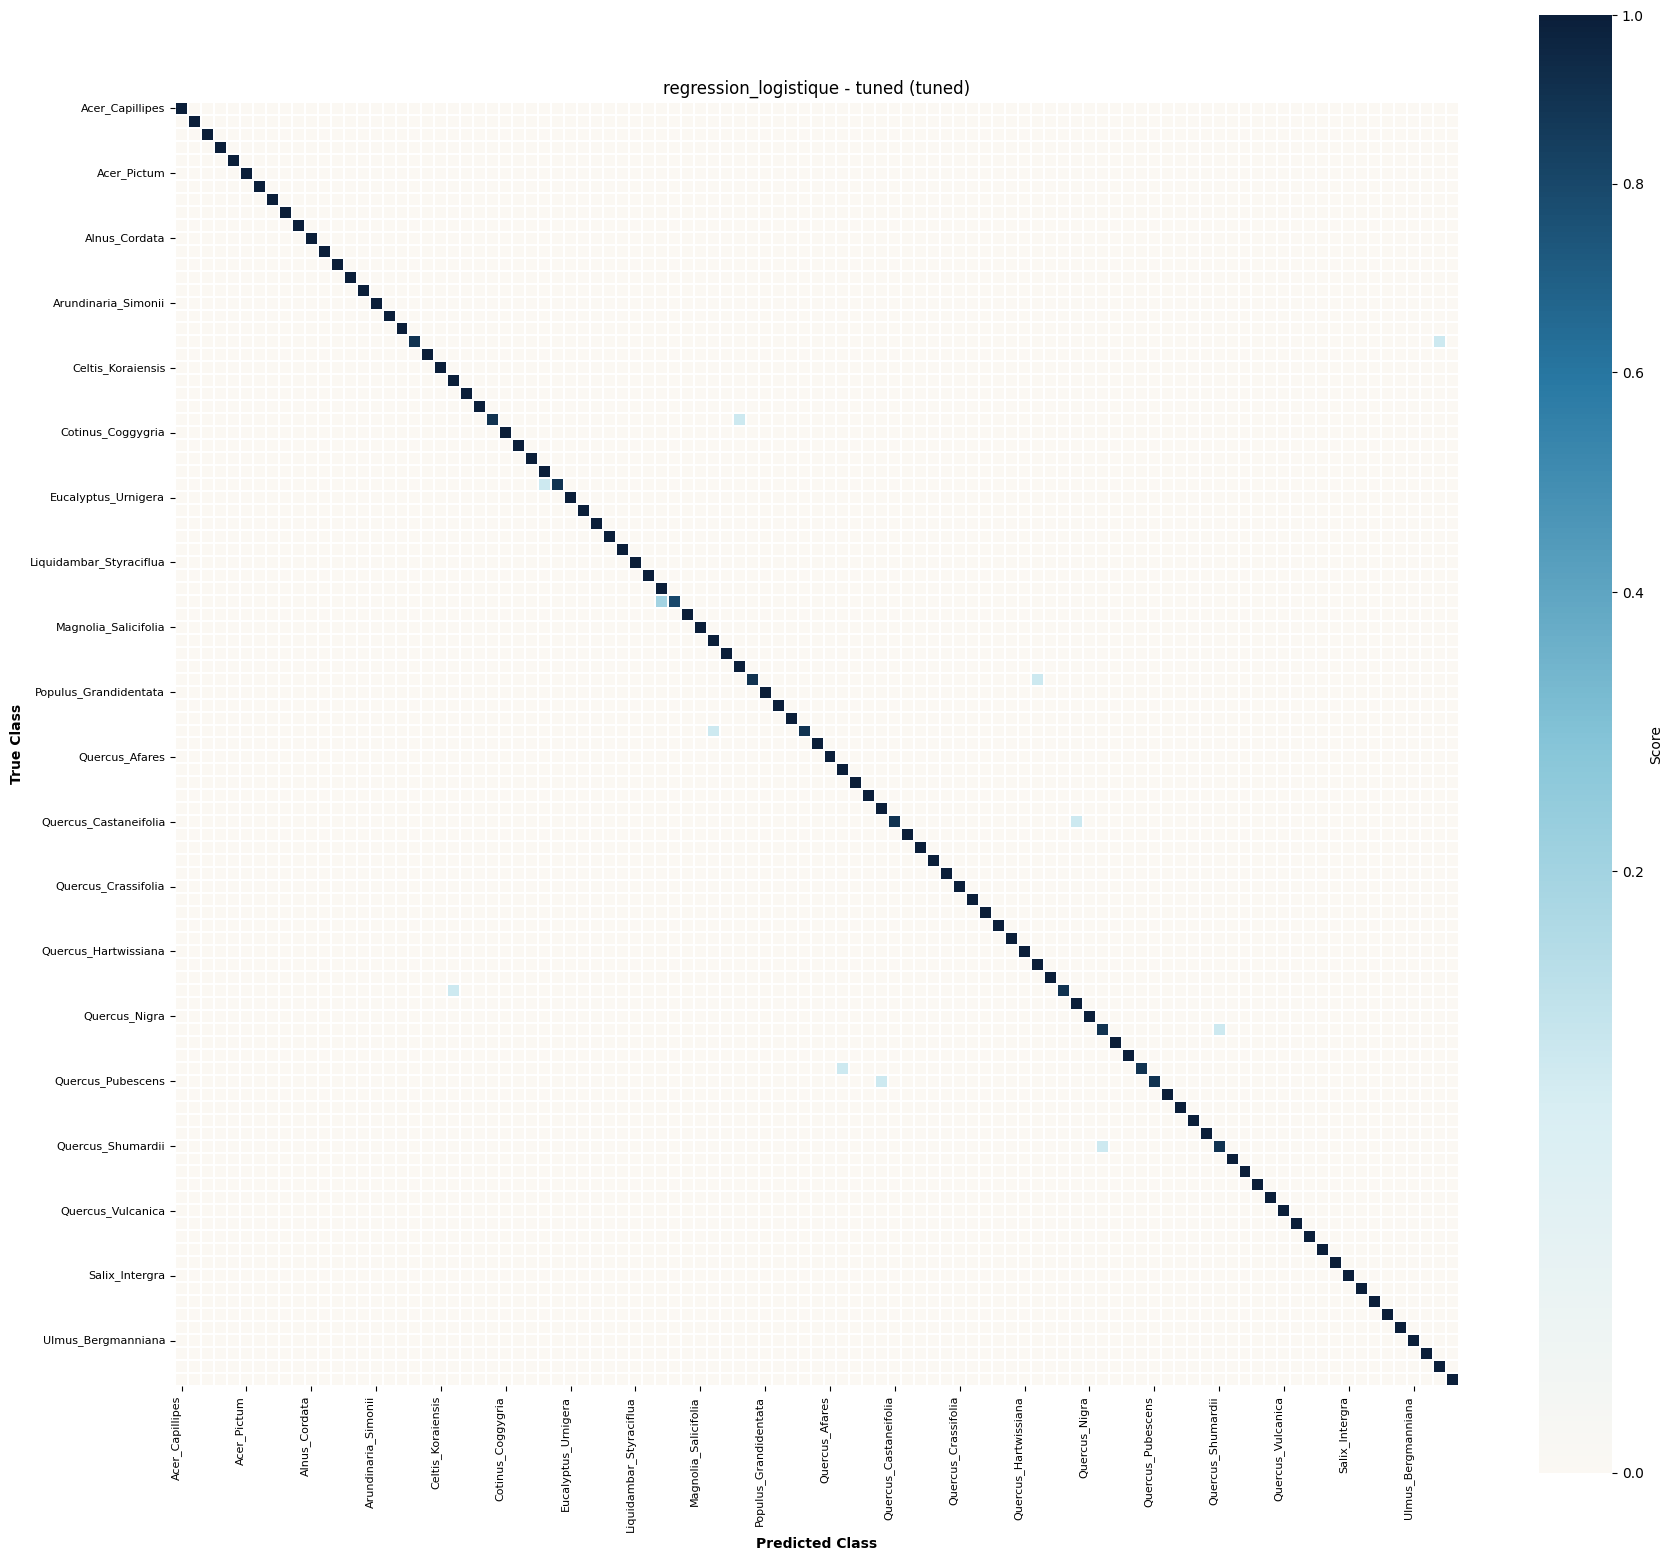

### svm

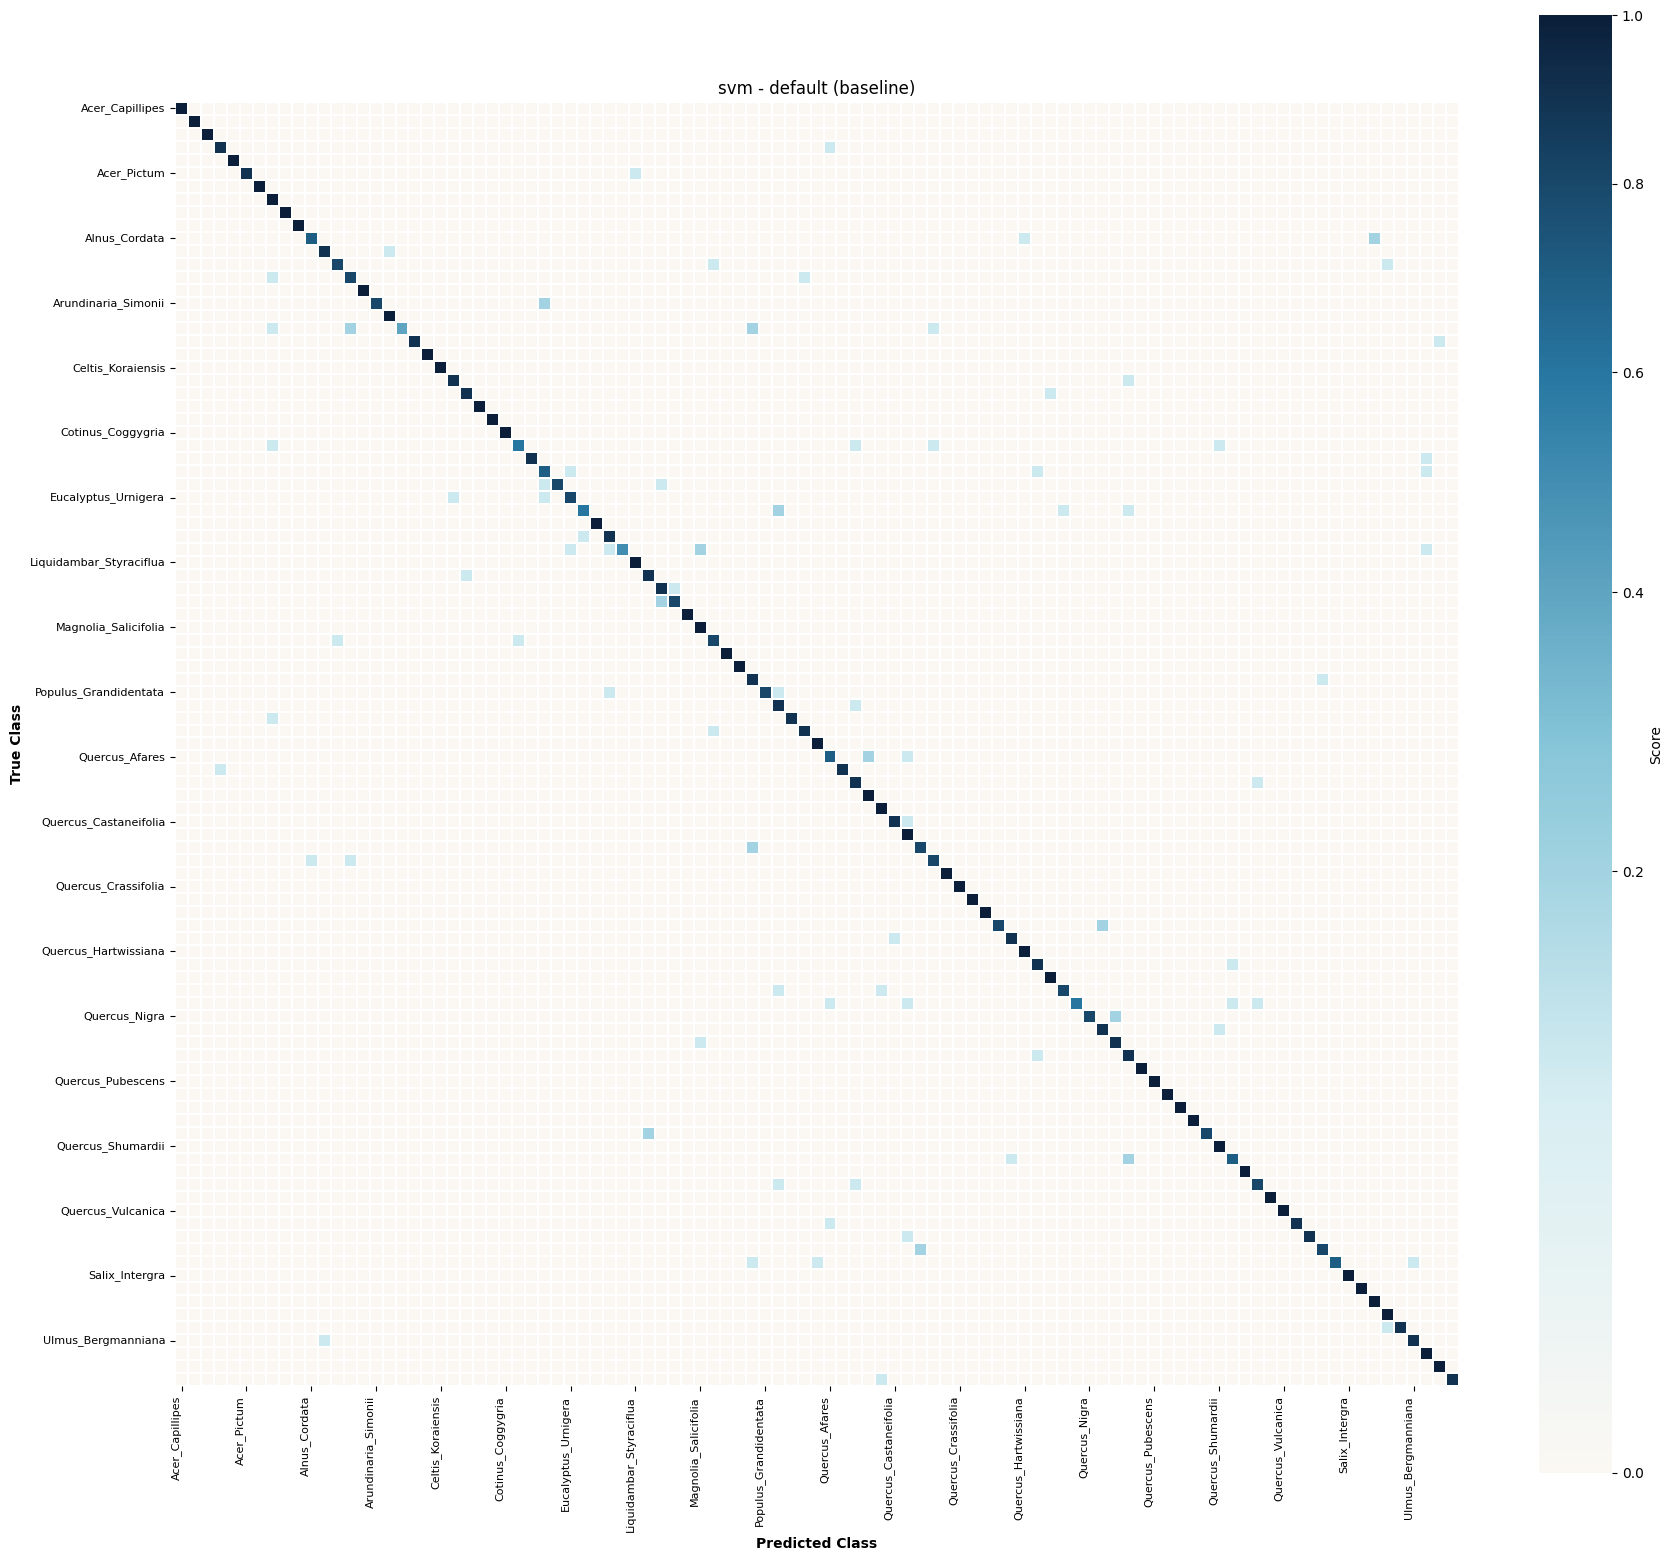

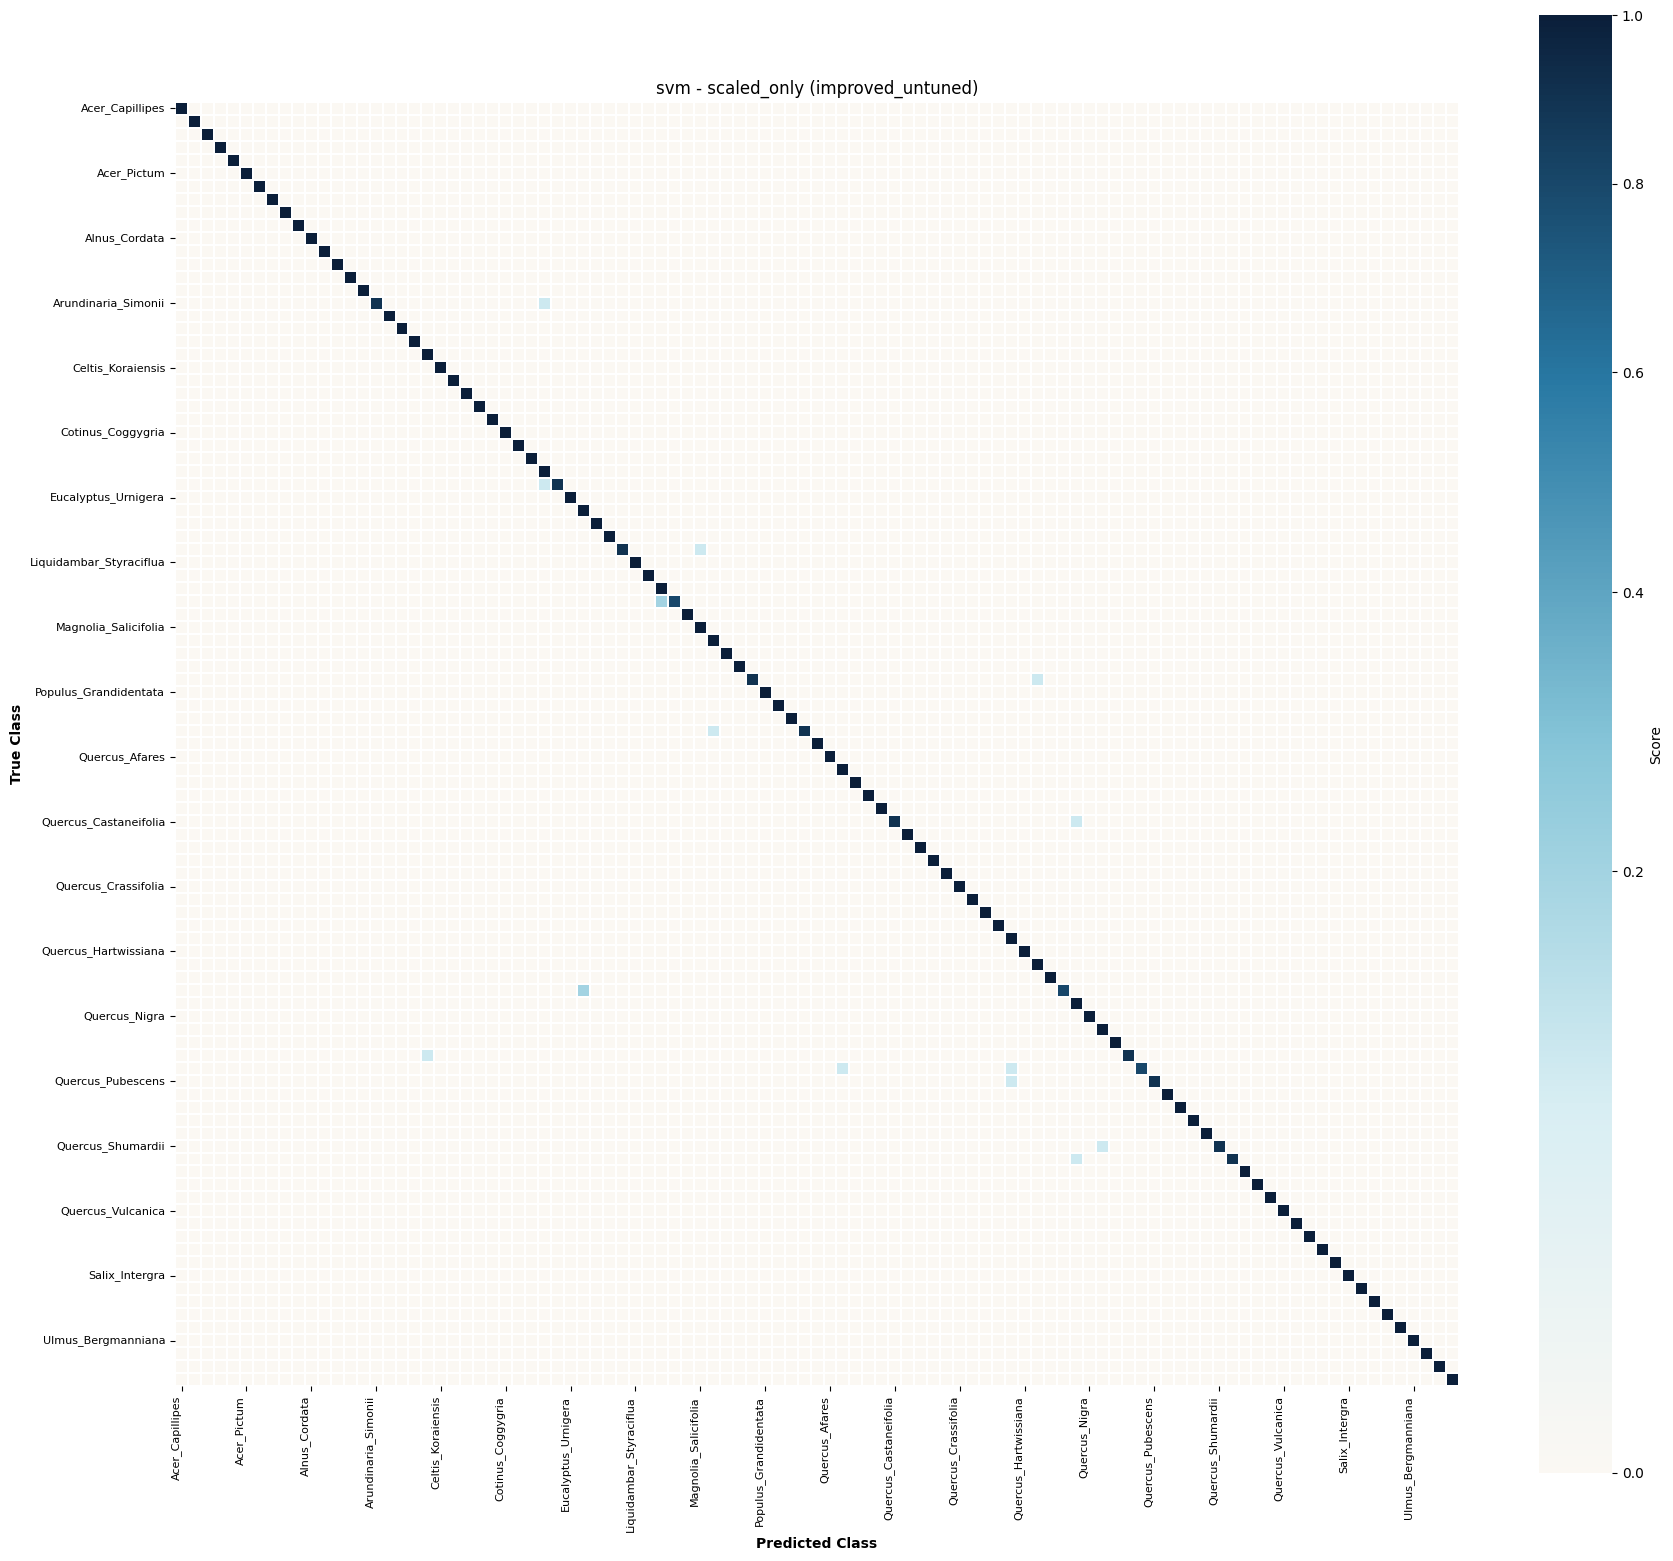

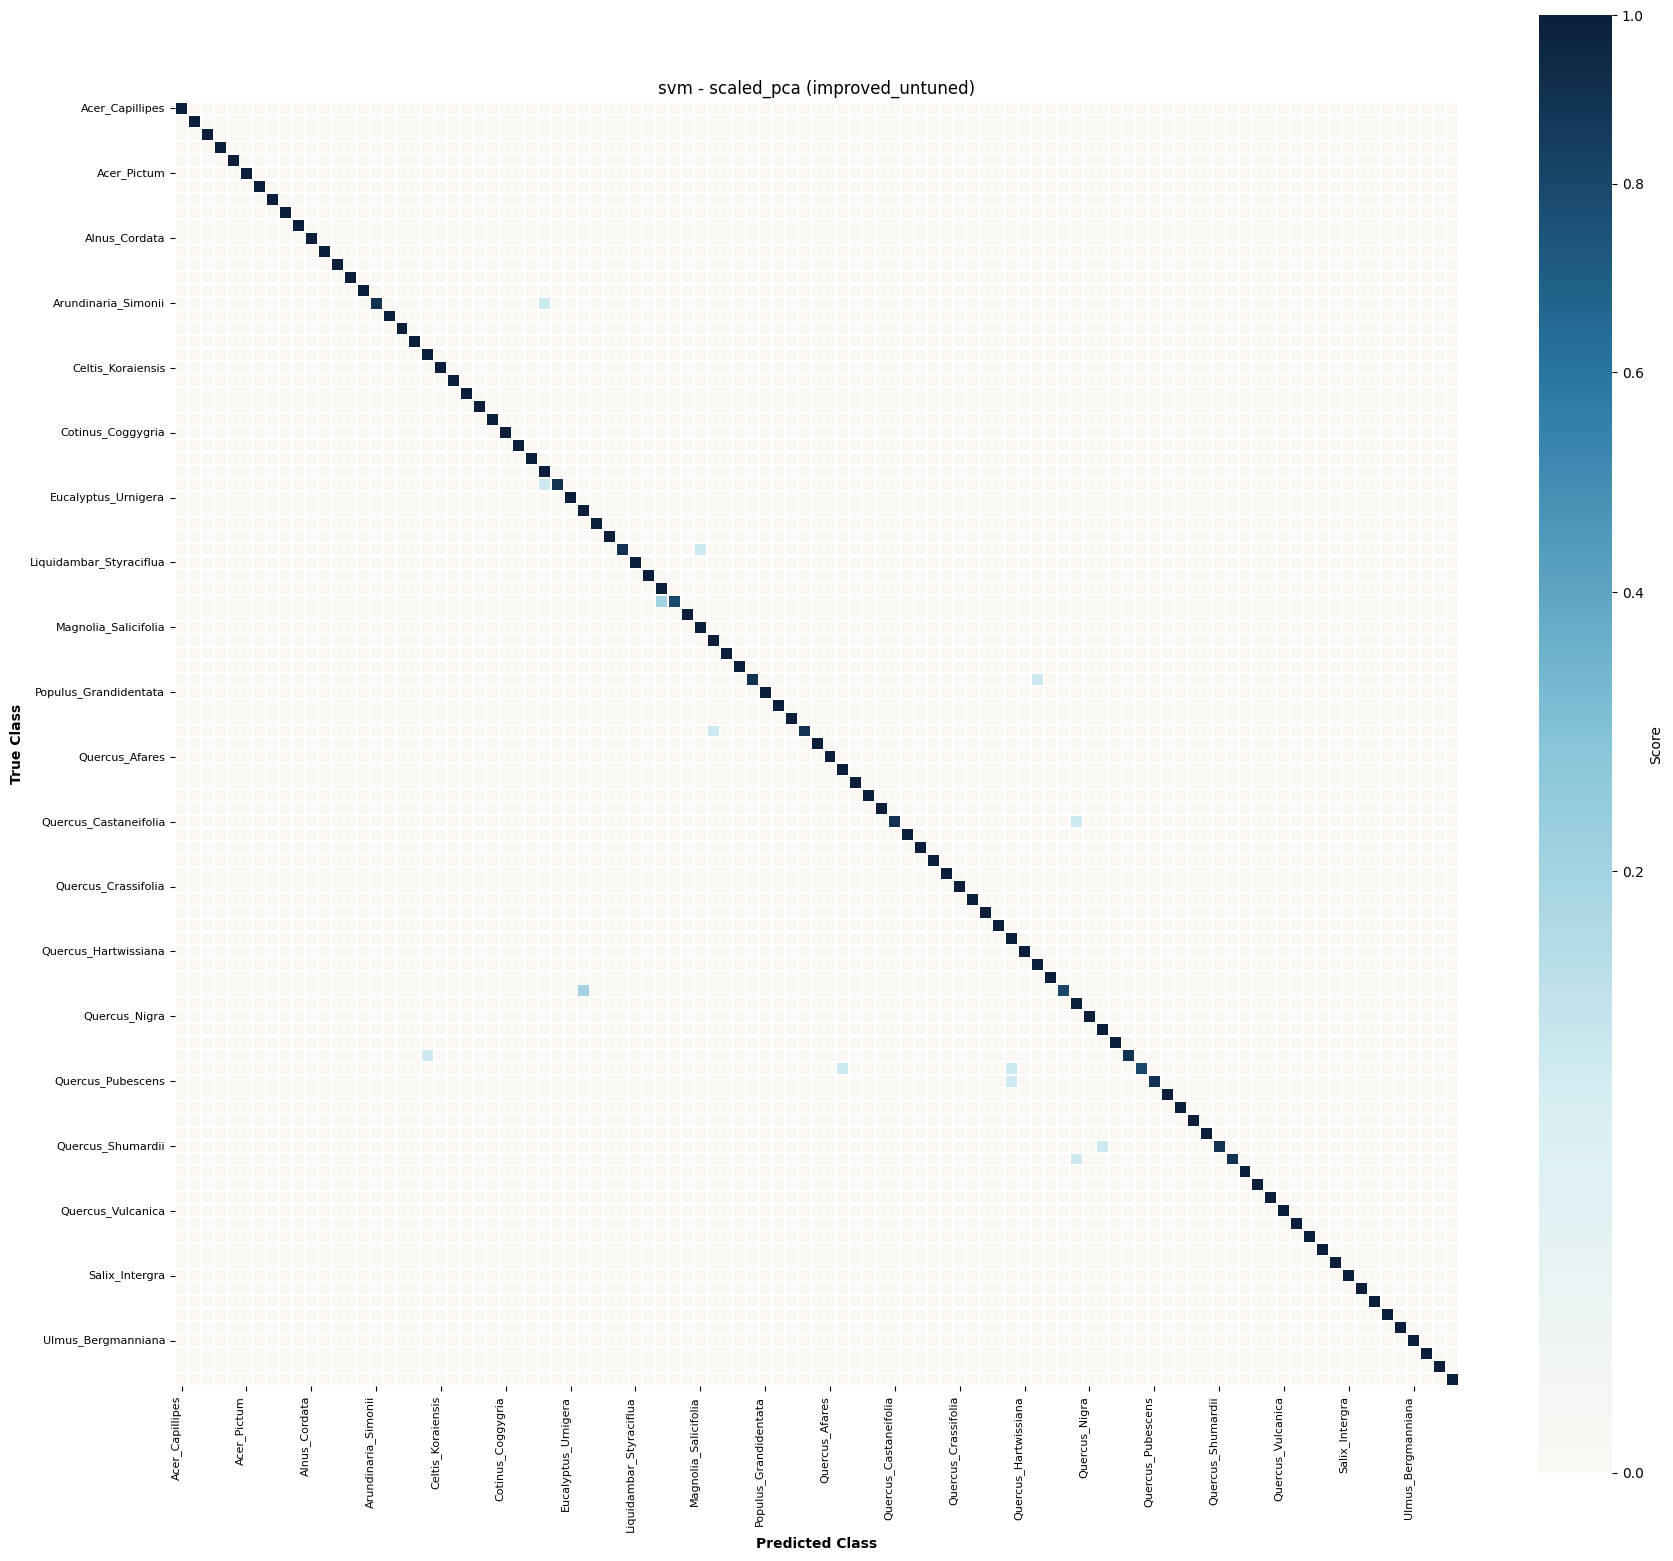

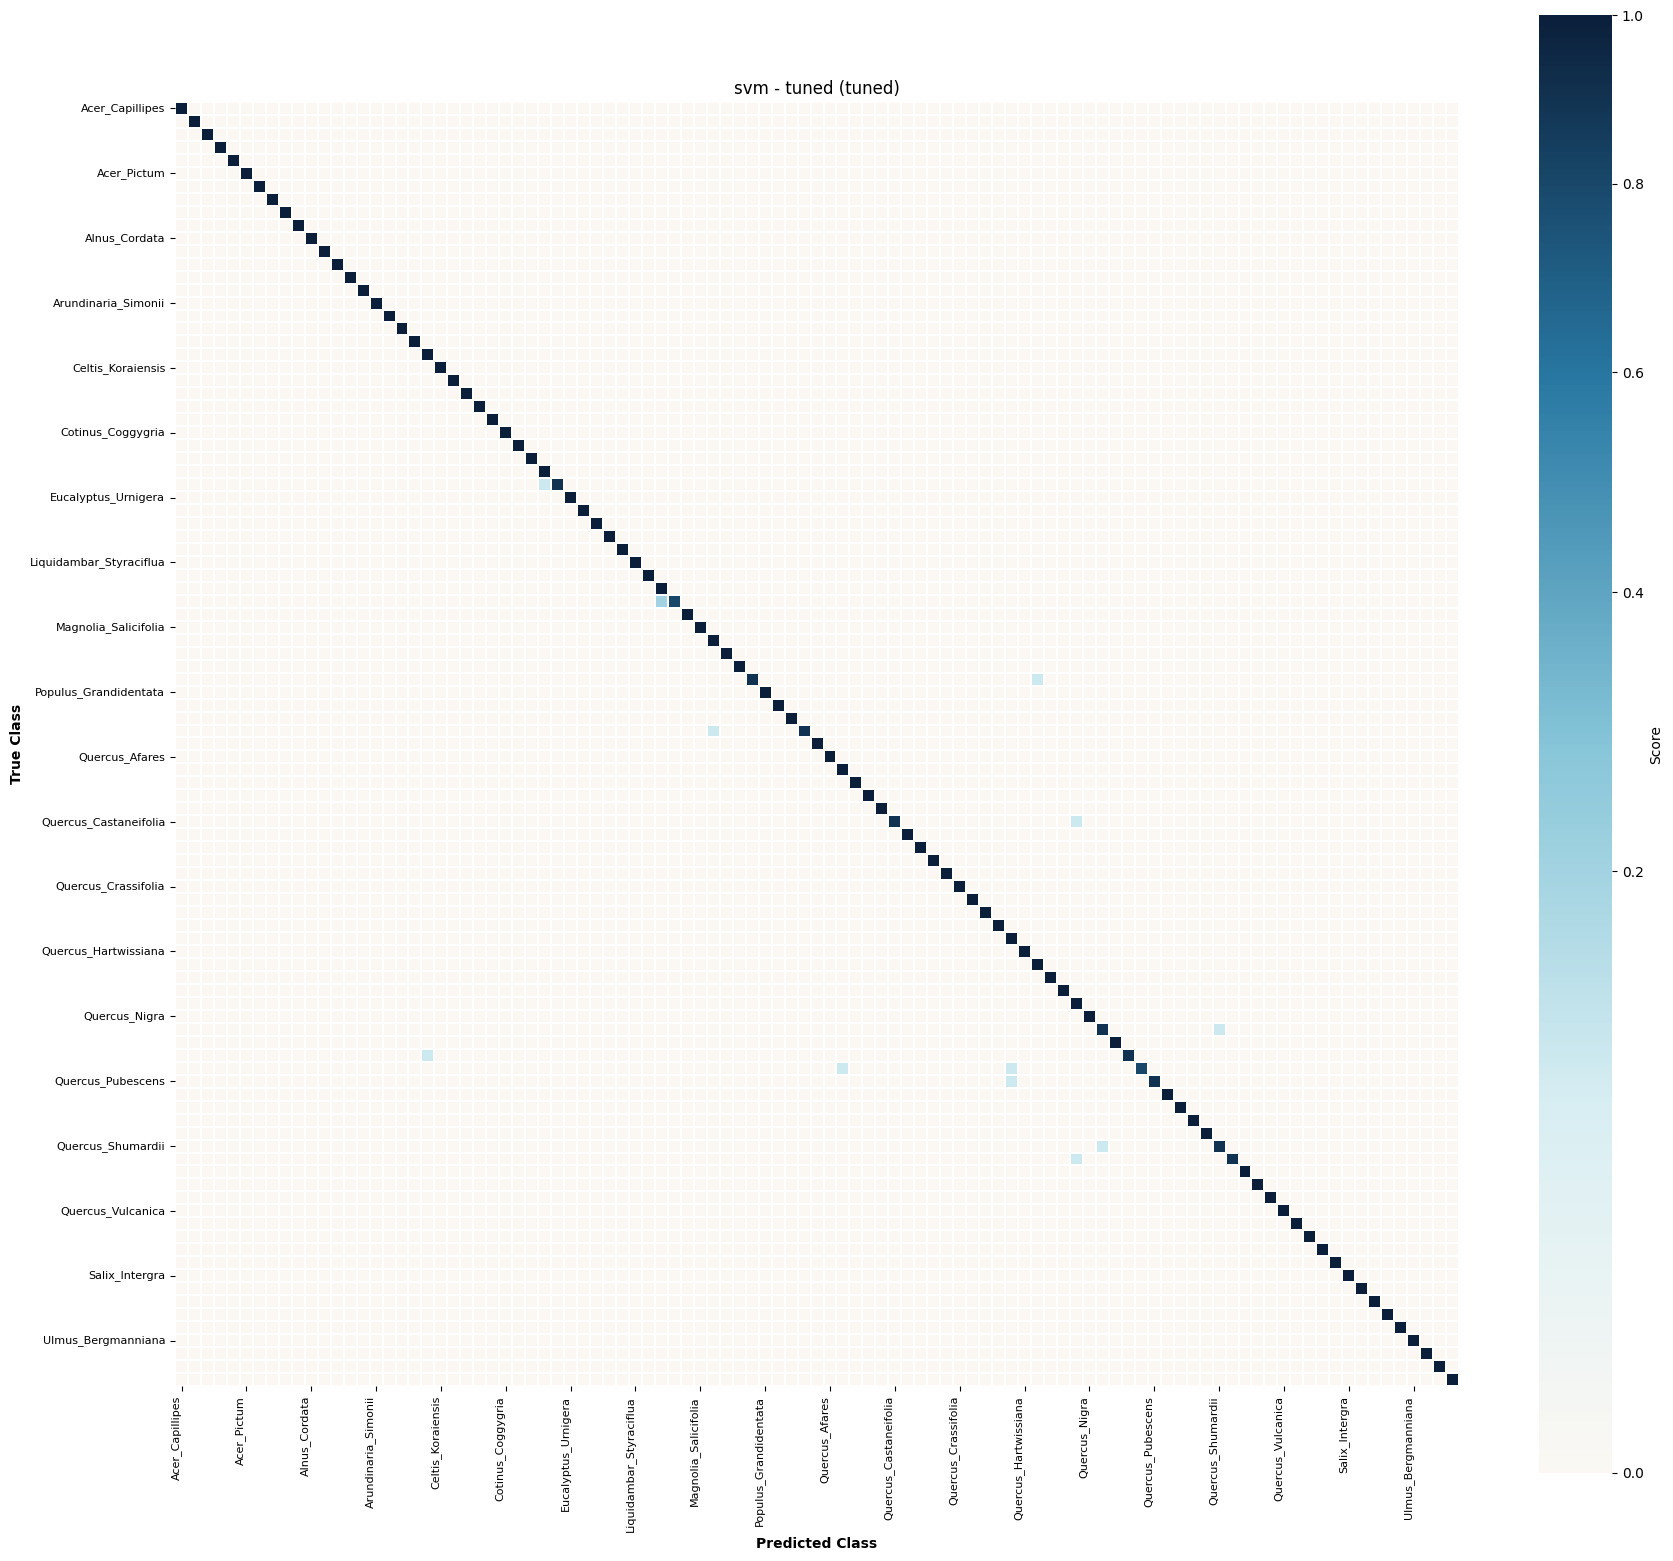

In [7]:
ordre_variantes = {
    "default": 0,
    "scaled_only": 1,
    "scaled_pca": 2,
    "restricted_depth": 3,
    "tuned": 99,
}

catalogue_variantes = (
    mesures[["modele", "variante", "evaluation_stage"]]
    .drop_duplicates()
    .assign(
        modele=lambda df: df["modele"].astype("string"),
        variante=lambda df: df["variante"].astype("string"),
        _ordre=lambda df: df["variante"].map(lambda v: ordre_variantes.get(str(v), 50)),
    )
    .sort_values(["modele", "_ordre", "variante"])
    .reset_index(drop=True)
)

predictions_cache = {}

for modele, sous_tableau in catalogue_variantes.groupby("modele"):
    nom_modele = str(modele)
    display(Markdown(f"### {nom_modele}"))
    for ligne in sous_tableau.to_dict("records"):
        variante = str(ligne["variante"])
        cle = (nom_modele, variante)
        if cle not in predictions_cache:
            predictions_cache[cle] = charger_ou_generer_predictions_variante(
                nom_modele,
                variante,
                X,
                y,
                label_encoder=label_encoder,
                root=OUTPUT_ROOT,
            )

        predictions_variante = predictions_cache[cle]
        matrice = matrice_confusion_normalisee(
            predictions_variante["y_true"].to_numpy(),
            predictions_variante["y_pred"].to_numpy(),
                label_encoder=label_encoder,
            )
        ax = tracer_matrice_confusion(
            matrice,
            titre=f"{nom_modele} - {variante} ({ligne['evaluation_stage']})",
            annot=False,
            intervalle_ticks=5,
        )
        plt.show()


### Complementarite potentielle des erreurs

Le tableau suivant compare les meilleurs candidats `tuned` en termes de desaccord et de recouvrement des erreurs.
Il sert a preparer une hypothese d'ensemble sans conclure qu'une combinaison est deja justifiee.


In [8]:
predictions_top = {modele: charger_predictions_modele(modele, "tuned", root=OUTPUT_ROOT) for modele in best_tuned.head(3)["modele"]}
complementarite = construire_tableau_complementarite_erreurs(predictions_top)
display(complementarite.round(4))


,modele_a,modele_b,disagreement_rate,error_overlap_rate,corriges_par_a_seul,corriges_par_b_seul
0,regression_logistique,svm,0.0071,0.0101,3,3
1,regression_logistique,foret_aleatoire,0.0253,0.0051,14,8
2,svm,foret_aleatoire,0.0263,0.0040,15,9


## 6. Interpretation

Cette section formule uniquement des hypotheses de travail a partir des artefacts charges.
Elle ne clot pas le classement ; les tableaux de stabilite inter-plis et de complementarite des erreurs servent uniquement a encadrer la discussion avant toute conclusion sur un ensemble.


In [9]:
top_2 = best_tuned.head(2).copy()
modeles_gain_preprocessing = best_exploratoire.loc[
    best_exploratoire["delta_f1_vs_default"] > 0.05, "modele"
].tolist()

lignes = [
    "- Hypothese 1 : le classement confirmatoire provisoire doit rester borne aux lignes `tuned` en `nested_cv`; les autres variantes ne servent qu'a expliquer les signaux observes.",
    f"- Hypothese 2 : `{top_2.iloc[0]['modele']}` et `{top_2.iloc[1]['modele']}` constituent actuellement le peloton de tete confirmatoire, mais l'ecart doit etre lu avec prudence a partir de la variabilite inter-plis.",
    f"- Hypothese 3 : les modeles les plus sensibles au preprocessing semblent etre {modeles_gain_preprocessing}, ce qui suggere que le scaling joue un role explicatif important dans leur performance finale.",
    "- Hypothese 4 : avant de proposer une combinaison de modeles, il faudra verifier si les meilleurs candidats commettent des erreurs complementaires plutot que redondantes.",
    f"- Hypothese 5 : le candidat confirmatoire courant `{candidat_courant}` merite une analyse d'erreurs plus fine, mais son rang actuel ne vaut pas encore conclusion definitive.",
]
display(Markdown("\n".join(lignes)))


- Hypothese 1 : le classement confirmatoire provisoire doit rester borne aux lignes `tuned` en `nested_cv`; les autres variantes ne servent qu'a expliquer les signaux observes.
- Hypothese 2 : `regression_logistique` et `svm` constituent actuellement le peloton de tete confirmatoire, mais l'ecart doit etre lu avec prudence a partir de la variabilite inter-plis.
- Hypothese 3 : les modeles les plus sensibles au preprocessing semblent etre ['mlp', 'perceptron', 'regression_logistique', 'svm'], ce qui suggere que le scaling joue un role explicatif important dans leur performance finale.
- Hypothese 4 : avant de proposer une combinaison de modeles, il faudra verifier si les meilleurs candidats commettent des erreurs complementaires plutot que redondantes.
- Hypothese 5 : le candidat confirmatoire courant `regression_logistique` merite une analyse d'erreurs plus fine, mais son rang actuel ne vaut pas encore conclusion definitive.

## 7. Corroboration secondaire sur holdout

Le tableau suivant reste strictement secondaire. Il confronte, pour les modèles éligibles, la performance `tuned` sur holdout à celle de la meilleure variante non tunée choisie sur le jeu de développement.
Il ne doit pas être utilisé pour redéfinir le classement principal, qui repose toujours sur les lignes `tuned` en `nested CV`.


In [ ]:
holdout_global = construire_tableau_holdout_global(model_names, root=OUTPUT_ROOT)
if holdout_global.empty:
    display(Markdown("_Aucune corroboration holdout disponible dans les artefacts canoniques._"))
else:
    display(holdout_global.sort_values("nested_cv_f1", ascending=False).round(4))
